# Signal Evaluation Framework  

---
### Sections
1. Setup & Configuration  
2. Data Loading  
3. Signal Generation  
4. Core Helpers  
5. Lookahead Bias Check
5. Compute Base Metrics
5. Walk-Forward Optimization
6. Combinatorial Purging + Embargo Cross-Validation
7. Probability of Backtest Overfitting
8. False Discovery Rate
7. Expected Shortfall Curves + Drawdown Duration Distribution
8. Research Quality Score With Gates



# Setup & Configuration

In [1]:
# ==============================================================================
# CELL 1: SETUP & CONFIGURATION (USER ADJUSTABLE)
# ==============================================================================
import os
import sys
import warnings
import itertools
import math
import numpy as np
import pandas as pd
import io
import contextlib
import inspect
import importlib.util
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, norm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
plt.style.use("seaborn-v0_8-whitegrid")

TRAIN_START = "2004-11-18"
TRAIN_END = "2018-12-31"
TEST_START = "2019-01-01"
TEST_END = "2023-12-31"

SIGNAL_MODULE_DIR = "/content/drive/My Drive/Prometheus/First cycle/"

# Constants
TRANSACTION_COST_BPS = 5.0
SLIPPAGE_BPS = 2.0
EULER_MASCHERONI = 0.5772156649015329

# Statistical controls
NW_LAGS = 5
ES_ALPHAS =[0.01, 0.025, 0.05, 0.10]
N_CPCV_FOLDS = 10
CPCV_TEST_BLOCKS = 2
EMBARGO_DAYS = 10
MIN_OBS_PER_SPLIT = 120
WFO_TRAIN_YEARS = 5
WFO_TEST_YEARS = 1

# Research quality gates
GATE_MIN_TEST_SHARPE = 0.40
GATE_MAX_TURNOVER = 0.40
GATE_MIN_DSR = 0.50
GATE_MAX_PBO = 0.60

print("Cell 1: Setup complete.")

Cell 1: Setup complete.


# Data Loading

In [2]:
# ==============================================================================
# CELL 2: DATA LOADING
# ==============================================================================
from google.colab import drive
if not os.path.exists("/content/drive/My Drive"):
    drive.mount("/content/drive")

SIGNAL_MODULE_DIR = "/content/drive/My Drive/Prometheus/First cycle/"
BACKTEST_MODULE_DIR = SIGNAL_MODULE_DIR

sys.path.insert(0, SIGNAL_MODULE_DIR)

# ------------------------------------------------------------------------------
# PART 1: SIGNALS MODULE
# ------------------------------------------------------------------------------
sig_module_name = "cycle_1_signals"
sig_module_path = os.path.join(SIGNAL_MODULE_DIR, f"{sig_module_name}.py")
if not os.path.exists(sig_module_path):
    raise FileNotFoundError(f"Could not find {sig_module_name}.py at: {sig_module_path}")

sig_spec = importlib.util.spec_from_file_location(sig_module_name, sig_module_path)
cycle_1_signals = importlib.util.module_from_spec(sig_spec)

cycle_1_signals.families = []
sys.modules[sig_module_name] = cycle_1_signals

# Suppress module-level prints/warnings
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        sig_spec.loader.exec_module(cycle_1_signals)

if not hasattr(cycle_1_signals, "DataLoader"):
    raise AttributeError("cycle_1_signals.py does not expose DataLoader")

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        data_dict = cycle_1_signals.DataLoader().load_data()

full_df = data_dict["GLD"].copy()
full_df["Ret"] = full_df["Close"].pct_change().fillna(0)

train_mask = (full_df.index >= TRAIN_START) & (full_df.index <= TRAIN_END)
test_mask = (full_df.index >= TEST_START) & (full_df.index <= TEST_END)

BaseSignalFamily = cycle_1_signals.BaseSignalFamily
SIGNAL_FAMILY_CLASSES = sorted(
    [cls for _, cls in inspect.getmembers(cycle_1_signals, inspect.isclass)
     if issubclass(cls, BaseSignalFamily) and cls is not BaseSignalFamily],
    key=lambda c: c.__name__)

# ------------------------------------------------------------------------------
# PART 2: BACKTESTS MODULE
# ------------------------------------------------------------------------------
bt_module_name = "cycle_1_backtests"
bt_module_path = os.path.join(BACKTEST_MODULE_DIR, f"{bt_module_name}.py")
if not os.path.exists(bt_module_path):
    raise FileNotFoundError(f"Could not find {bt_module_name}.py at: {bt_module_path}")

bt_spec = importlib.util.spec_from_file_location(bt_module_name, bt_module_path)
cycle_1_backtests = importlib.util.module_from_spec(bt_spec)

cycle_1_backtests.families = []
sys.modules[bt_module_name] = cycle_1_backtests

# Suppress module-level prints/warnings
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        bt_spec.loader.exec_module(cycle_1_backtests)

if not hasattr(cycle_1_backtests, "BaseBacktestFamily"):
    raise AttributeError("cycle_1_backtests.py does not expose BaseBacktestFamily")

BaseBacktestFamily = cycle_1_backtests.BaseBacktestFamily
BACKTEST_FAMILY_CLASSES = sorted(
    [cls for _, cls in inspect.getmembers(cycle_1_backtests, inspect.isclass)
     if issubclass(cls, BaseBacktestFamily) and cls is not BaseBacktestFamily],
    key=lambda c: c.__name__)

backtest_families = [cls(data_dict) for cls in BACKTEST_FAMILY_CLASSES]

all_results = []
summary_rows = []
total_backtests = 0

daily_returns_registry = pd.DataFrame(index=full_df.index)

for family in backtest_families:
    fam_name = family.__class__.__name__
    fam_prefix = fam_name.replace("Family", "")

    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                out = family.run()

        if isinstance(out, tuple) and len(out) >= 2:
            count, results = out[0], out[1]
        elif isinstance(out, list):
            results, count = out, len(out)
        elif isinstance(out, dict):
            results, count = [out], 1
        elif out is None:
            results = getattr(family, "results", [])
            count = len(results)
        else:
            results = getattr(family, "results", [])
            count = len(results)

        if results is None:
            results = []
        if isinstance(results, dict):
            results = [results]
        if not isinstance(results, list):
            results = []

        normalized = []
        for r in results:
            if isinstance(r, dict):
                row = dict(r)
                row.setdefault("Family", fam_name)
                normalized.append(row)

        all_results.extend(normalized)
        total_backtests += int(count)
        summary_rows.append({
            "Family": fam_name,
            "Backtests_Ran": int(count),
            "Rows_Collected": len(normalized)})

        fam_registry = getattr(family, "daily_returns_registry", None)
        if isinstance(fam_registry, pd.DataFrame) and fam_registry.shape[1] > 0:
            fam_registry = fam_registry.reindex(full_df.index)

            fam_registry = fam_registry.rename(columns=lambda c: f"{fam_prefix}__{c}")

            daily_returns_registry = pd.concat([daily_returns_registry, fam_registry], axis=1)

    except Exception as e:
        summary_rows.append({
            "Family": fam_name,
            "Backtests_Ran": 0,
            "Rows_Collected": 0,
            "Error": str(e)})

if daily_returns_registry.shape[1] > 0:
    daily_returns_registry = daily_returns_registry.loc[:, ~daily_returns_registry.columns.duplicated(keep="first")]

df_backtests = pd.DataFrame(all_results)
df_backtest_summary = pd.DataFrame(summary_rows)

# ------------------------------------------------------------------------------
# Part 3: OUTPUT
# ------------------------------------------------------------------------------

# Name mismatch diagnostic
def normalize_family_name(name: str) -> str:
    s = str(name)
    s = s.replace("Signals", "").replace("Family", "")
    s = s.strip()
    return s

signal_family_names = [cls.__name__.replace("Signals", "") for cls in SIGNAL_FAMILY_CLASSES]
backtest_family_names = [cls.__name__.replace("Family", "") for cls in BACKTEST_FAMILY_CLASSES]

signal_norm = sorted({normalize_family_name(x) for x in signal_family_names})
backtest_norm = sorted({normalize_family_name(x) for x in backtest_family_names})

only_in_signals = sorted(set(signal_norm) - set(backtest_norm))
only_in_backtests = sorted(set(backtest_norm) - set(signal_norm))
in_both = sorted(set(signal_norm).intersection(set(backtest_norm)))

print("\nSignal family names (raw):")
for n in sorted(signal_family_names):
    print(" -", n)

print("\nBacktest family names (raw):")
for n in sorted(backtest_family_names):
    print(" -", n)

print("\nNormalized family names in BOTH:")
for n in in_both:
    print(" -", n)

print("\nNormalized names only in SIGNALS:")
for n in only_in_signals:
    print(" -", n)

print("\nNormalized names only in BACKTESTS:")
for n in only_in_backtests:
    print(" -", n)

print(f"\nDiscovered {len(SIGNAL_FAMILY_CLASSES)} signal families")
print(f"Data Loaded! Train rows: {train_mask.sum()} | Test rows: {test_mask.sum()}")
print(f"Discovered {len(BACKTEST_FAMILY_CLASSES)} backtest families")
print(f"Instantiated {len(backtest_families)} backtest family objects")
print(f"Total backtests reported: {total_backtests}")
print(f"daily_returns_registry shape: {daily_returns_registry.shape}")

display(df_backtest_summary)

Mounted at /content/drive

Signal family names (raw):
 - AsymmetricVolatility
 - Autocorrelation
 - Fibonacci
 - HurstExponent
 - LongTermTrend
 - MarketEfficiencyAndNoise
 - MediumTermTrend
 - ReturnConcentration
 - Seasonality
 - ShortOnly
 - ShortTermTrend
 - Volatility
 - VolatilityMomentum
 - Volume
 - VolumeVolatilityIntersection

Backtest family names (raw):
 - AsymmetricVolatility
 - Autocorrelation
 - Fibonacci
 - HurstExponent
 - LongTermTrend
 - MarketEfficiencyAndNoise
 - MediumTermTrend
 - ReturnConcentration
 - Seasonality
 - ShortOnly
 - ShortTermTrend
 - Volatility
 - VolatilityMomentum
 - Volume
 - VolumeVolatilityIntersection

Normalized family names in BOTH:
 - AsymmetricVolatility
 - Autocorrelation
 - Fibonacci
 - HurstExponent
 - LongTermTrend
 - MarketEfficiencyAndNoise
 - MediumTermTrend
 - ReturnConcentration
 - Seasonality
 - ShortOnly
 - ShortTermTrend
 - Volatility
 - VolatilityMomentum
 - Volume
 - VolumeVolatilityIntersection

Normalized names only in SIGN

,Family,Backtests_Ran,Rows_Collected
0,AsymmetricVolatilityFamily,354,354
1,AutocorrelationFamily,634,634
2,FibonacciFamily,892,892
3,HurstExponentFamily,991,991
4,LongTermTrendFamily,632,632
5,MarketEfficiencyAndNoiseFamily,644,644
6,MediumTermTrendFamily,740,740
7,ReturnConcentrationFamily,1285,1285
8,SeasonalityFamily,630,630
9,ShortOnlyFamily,483,483


# Signal Generation

In [3]:
# ==============================================================================
# CELL 3: SIGNAL GENERATION
# ==============================================================================
print("Generating signals from discovered families...")

ALL_SIGS_PRE = {}
SIG_GROUPS_PRE = {}
duplicate_signal_names = []

for family_cls in SIGNAL_FAMILY_CLASSES:
    fam_name = family_cls.__name__.replace("Signals", "")
    family = family_cls(data_dict)

    family.generate_signals()
    if hasattr(family, "enforce_point_in_time_signals"):
        family.enforce_point_in_time_signals(lag=1)

    raw_sigs = family.signals if isinstance(family.signals, dict) else {}

    prefixed_sigs = {f"{fam_name}__{sig_name}": sig_val for sig_name, sig_val in raw_sigs.items()}

    overlap = set(ALL_SIGS_PRE.keys()).intersection(prefixed_sigs.keys())
    if overlap:
        duplicate_signal_names.extend(sorted(overlap))

    ALL_SIGS_PRE.update(prefixed_sigs)
    SIG_GROUPS_PRE[fam_name] = list(prefixed_sigs.keys())

BH = pd.Series(1.0, index=full_df.index, name="Buy & Hold")

print(f"\n✅ {len(ALL_SIGS_PRE)} signals generated across {len(SIG_GROUPS_PRE)} families")
for grp, keys in SIG_GROUPS_PRE.items():
    print(f"   {grp:20s}: {len(keys):3d} signals")

if duplicate_signal_names:
    print(f"\nDuplicate signal names detected ({len(set(duplicate_signal_names))} unique).")
    print("   Example duplicates:", sorted(set(duplicate_signal_names))[:10])

Generating signals from discovered families...

✅ 102 signals generated across 15 families
   AsymmetricVolatility:   4 signals
   Autocorrelation     :   3 signals
   Fibonacci           :  10 signals
   HurstExponent       :   7 signals
   LongTermTrend       :  10 signals
   MarketEfficiencyAndNoise:   3 signals
   MediumTermTrend     :   9 signals
   ReturnConcentration :   3 signals
   Seasonality         :   7 signals
   ShortOnly           :   9 signals
   ShortTermTrend      :   8 signals
   VolatilityMomentum  :  10 signals
   Volatility          :   3 signals
   Volume              :   8 signals
   VolumeVolatilityIntersection:   8 signals


# Core Helpers

sanitize_signal:
$$
s_t=\mathrm{clip}(\tilde{s}_t,-1,1),\qquad
\tilde{s}_t=
\begin{cases}
\text{sig}_t,& \text{if observed}\\
0,& \text{if missing}
\end{cases}
$$

compute_returns:
$$
r^{\text{gross}}_t=s_t\,r^{\text{mkt}}_t,\qquad
\text{turnover}_t=\lvert s_t-s_{t-1}\rvert
$$
$$
c=\frac{\text{tc\_bps}+\text{slip\_bps}}{10{,}000},\qquad
\text{cost}_t=c\cdot \text{turnover}_t,\qquad
r^{\text{net}}_t=r^{\text{gross}}_t-\text{cost}_t
$$

max_drawdown:
$$
DD_t=\frac{W_t}{\max_{u\le t}W_u}-1,\qquad
\text{MaxDD}=\min_t DD_t
$$

newey_west_se_mean:
$$
x_t=r_t-\bar r,\qquad
\gamma_0=\frac{1}{n}\sum_{t=1}^{n}x_t^2,\qquad
\gamma_k=\frac{1}{n}\sum_{t=k+1}^{n}x_t\,x_{t-k}
$$
$$
w_k=1-\frac{k}{L+1},\qquad
\widehat{\sigma}^2_{LR}=\gamma_0+2\sum_{k=1}^{L}w_k\,\gamma_k,\qquad
SE(\bar r)=\sqrt{\frac{\widehat{\sigma}^2_{LR}}{n}}
$$

sharpe_stats:
$$
\mu=\bar r,\quad \sigma=\mathrm{sd}(r),\quad n=|r|,\qquad
SR_d=\frac{\mu}{\sigma},\qquad
SR_{\text{ann}}=\sqrt{252}\,SR_d
$$
$$
t_\mu=\frac{\mu}{SE(\mu)},\qquad
p_\mu=2\left(1-\Phi\left(|t_\mu|\right)\right)
$$
$$
SE(SR_d)=\sqrt{\frac{1+\tfrac{1}{2}SR_d^2}{n-1}},\qquad
t_{SR}=\frac{SR_d}{SE(SR_d)},\qquad
p_{SR}=2\left(1-\Phi\left(|t_{SR}|\right)\right)
$$

deflated_sharpe_ratio (Bailey & López de Prado, 2014):
$$
z_1=\Phi^{-1}\left(1-\frac{1}{N}\right),\qquad
z_2=\Phi^{-1}\left(1-\frac{e^{-1}}{N}\right)
$$
$$
SR_0=\sqrt{\mathrm{Var}(\widehat{SR}_n)}\left((1-\gamma_{EM})z_1+\gamma_{EM}z_2\right)
$$
$$
D=1-\gamma_3\,SR+\frac{\gamma_4-1}{4}SR^2,\qquad
z=\frac{(SR-SR_0)\sqrt{T-1}}{\sqrt{D}},\qquad
DSR=\Phi(z)
$$

In [4]:
# ==============================================================================
# CELL 4: CORE HELPERS
# ==============================================================================
def _slice_window(df, TRAIN_START, TRAIN_END, TEST_START=None, TEST_END=None, window="train"):
    if window == "train":
        return df.loc[TRAIN_START:TRAIN_END].copy()

    if window == "test":
        if TEST_START is None or TEST_END is None:
            raise ValueError("TEST_START and TEST_END are required when window='test'")
        return df.loc[TEST_START:TEST_END].copy()

    if window == "full":
        end = TEST_END if TEST_END is not None else TRAIN_END
        return df.loc[TRAIN_START:end].copy()

    raise ValueError("window must be one of: 'train', 'test', 'full'")

def sanitize_signal(sig: pd.Series) -> pd.Series:
    return pd.Series(sig, index=full_df.index).fillna(0).astype(float).clip(-1, 1)

def compute_returns(sig: pd.Series, mask=None, tc_bps=TRANSACTION_COST_BPS, slip_bps=SLIPPAGE_BPS):
    s = sanitize_signal(sig)
    r_mkt = full_df["Ret"]
    gross = (s * r_mkt).fillna(0)

    prev_pos = s.shift(1).fillna(0)
    turnover = (s - prev_pos).abs()
    cost = turnover * ((tc_bps + slip_bps) / 10000.0)
    net = gross - cost

    if mask is not None:
        return gross[mask], net[mask], cost[mask], s[mask]
    return gross, net, cost, s

def max_drawdown(cum: pd.Series) -> float:
    dd = cum / cum.cummax() - 1
    return float(dd.min()) if len(dd) else 0.0

def newey_west_se_mean(ret: pd.Series, lags: int = NW_LAGS) -> float:
    x = np.asarray(ret.dropna(), dtype=float)
    n = len(x)
    if n < 3: return np.nan
    x = x - x.mean()
    lr_var = np.dot(x, x) / n
    for k in range(1, min(lags, n - 1) + 1):
        w = 1 - k / (lags + 1)
        gamma_k = np.dot(x[k:], x[:-k]) / n
        lr_var += 2 * w * gamma_k
    return float(np.sqrt(max(lr_var, 1e-18) / n))

def sharpe_stats(ret: pd.Series, nw_lags: int = NW_LAGS):
    r = ret.dropna()
    if len(r) < 10 or r.std() == 0:
        return dict(
            Sharpe=np.nan,
            Sharpe_daily=np.nan,
            Sharpe_annual=np.nan,
            Sharpe_t=np.nan, Sharpe_p=np.nan, Mean_t=np.nan, Mean_p=np.nan)

    mu, sd, n = r.mean(), r.std(), len(r)

    sr_daily = mu / sd
    sr_annual = np.sqrt(252) * sr_daily

    se_mu = newey_west_se_mean(r, lags=nw_lags)
    t_mu = mu / se_mu if se_mu > 0 else np.nan
    p_mu = 2 * (1 - norm.cdf(abs(t_mu))) if np.isfinite(t_mu) else np.nan

    se_sr_daily = np.sqrt((1 + 0.5 * sr_daily**2) / max(n - 1, 1))
    t_sr = sr_daily / se_sr_daily if se_sr_daily > 0 else np.nan
    p_sr = 2 * (1 - norm.cdf(abs(t_sr))) if np.isfinite(t_sr) else np.nan

    return dict(
        Sharpe=sr_annual,
        Sharpe_daily=sr_daily,
        Sharpe_annual=sr_annual,
        Sharpe_t=t_sr, Sharpe_p=p_sr, Mean_t=t_mu, Mean_p=p_mu)

def calc_effective_independent_trials(
    daily_returns_registry,
    TRAIN_START,
    TRAIN_END,
    TEST_START=None,
    TEST_END=None,
    window="train",
    label="signals"):
    strategy_returns = _slice_window(
        daily_returns_registry, TRAIN_START, TRAIN_END, TEST_START, TEST_END, window=window)
    M = strategy_returns.shape[1]

    if M <= 1:
        return float(M)

    corr_matrix = strategy_returns.corr()
    corr_values = corr_matrix.values
    off_diag_mask = ~np.eye(M, dtype=bool)
    off_diag_corrs = corr_values[off_diag_mask]

    rho_bar = np.nanmean(off_diag_corrs)
    if not np.isfinite(rho_bar):
        rho_bar = 0.0

    lower_bound = -1 / (M - 1)
    rho_bar_clipped = np.clip(rho_bar, lower_bound, 1)

    n_independent = rho_bar_clipped + (1 - rho_bar_clipped) * M
    return float(n_independent)

def compute_sr0(sr_estimates, n_independent):
    sr_estimates = np.asarray(sr_estimates, dtype=float)
    sr_estimates = sr_estimates[np.isfinite(sr_estimates)]

    if len(sr_estimates) < 2:
        return np.nan, np.nan

    n_trials = max(float(n_independent), 1.000001)
    variance_sr = np.var(sr_estimates, ddof=1)

    z1 = norm.ppf(1 - 1.0 / n_trials)
    z2 = norm.ppf(1 - 1.0 / (n_trials * np.e))
    sr0 = np.sqrt(max(variance_sr, 0.0)) * (
        (1 - EULER_MASCHERONI) * z1 +
        EULER_MASCHERONI * z2)
    return sr0, variance_sr

def calc_sr0_from_registry(
    daily_returns_registry,
    TRAIN_START,
    TRAIN_END,
    n_independent,
    TEST_START=None,
    TEST_END=None,
    window="train"):
    returns_window = _slice_window(
        daily_returns_registry, TRAIN_START, TRAIN_END, TEST_START, TEST_END, window=window)
    sr_estimates = returns_window.mean() / returns_window.std(ddof=1)
    sr_estimates = sr_estimates.replace([np.inf, -np.inf], np.nan).dropna()
    return compute_sr0(sr_estimates.values, n_independent)

def deflated_sharpe_ratio(
    sr_estimate: float,
    n_obs: int,
    n_trials: float = 10,
    skewness: float = 0.0,
    ex_kurt: float = 3.0,
    sr_estimates=None,
    var_sr_trials: float = None,
    return_inputs: bool = False):
    if not np.isfinite(sr_estimate) or n_obs < 30:
        out = np.nan
        inputs = {
            "VarSR": np.nan if var_sr_trials is None else float(var_sr_trials),
            "N": float(n_trials),
            "T": int(n_obs),
            "y3": float(skewness),
            "y4": float(ex_kurt)}
        return (out, inputs) if return_inputs else out

    T = int(n_obs)
    N = max(float(n_trials), 2.0)

    if var_sr_trials is not None and np.isfinite(var_sr_trials):
        gamma_em = EULER_MASCHERONI
        z1 = norm.ppf(1.0 - 1.0 / N)
        z2 = norm.ppf(1.0 - np.exp(-1.0) / N)
        sr0 = np.sqrt(max(float(var_sr_trials), 0.0)) * ((1.0 - gamma_em) * z1 + gamma_em * z2)
    elif sr_estimates is not None:
        sr0, var_sr_trials = compute_sr0(sr_estimates, N)
    else:
        # Fallback
        var_sr_trials = 0.5
        gamma_em = EULER_MASCHERONI
        z1 = norm.ppf(1.0 - 1.0 / N)
        z2 = norm.ppf(1.0 - np.exp(-1.0) / N)
        sr0 = np.sqrt(var_sr_trials) * ((1.0 - gamma_em) * z1 + gamma_em * z2)

    denom_inner = 1.0 - skewness * sr_estimate + ((ex_kurt - 1.0) / 4.0) * (sr_estimate ** 2)
    z_score = ((sr_estimate - sr0) * np.sqrt(max(T - 1, 1))) / np.sqrt(max(denom_inner, 1e-12))

    dsr = float(norm.cdf(z_score))
    inputs = {"VarSR": float(var_sr_trials), "N": float(N), "T": T, "y3": float(skewness), "y4": float(ex_kurt)}
    return (dsr, inputs) if return_inputs else dsr

# Lookahead Bias Check

In [5]:
# ==============================================================================
# CELL 5: LOOKAHEAD BIAS CHECK
# ==============================================================================
print("Running Lookahead Bias Check...")

LA_MIN_OBS = int(globals().get("LA_MIN_OBS", 504))
LA_MAX_NAN_RATE_WARN = float(globals().get("LA_MAX_NAN_RATE_WARN", 0.02))
LA_MAX_NAN_RATE_FAIL = float(globals().get("LA_MAX_NAN_RATE_FAIL", 0.05))

LA_MAX_ABS_SAMEDAY_CORR_WARN = float(globals().get("LA_MAX_ABS_SAMEDAY_CORR_WARN", 0.05))
LA_MAX_ABS_SAMEDAY_CORR_FAIL = float(globals().get("LA_MAX_ABS_SAMEDAY_CORR_FAIL", 0.08))

LA_MAX_SHARPE_GAP_WARN = float(globals().get("LA_MAX_SHARPE_GAP_WARN", 0.50))
LA_MAX_SHARPE_GAP_FAIL = float(globals().get("LA_MAX_SHARPE_GAP_FAIL", 0.75))

def _safe_ann_sharpe(r: pd.Series) -> float:
    r = pd.Series(r, dtype=float).replace([np.inf, -np.inf], np.nan).dropna()
    if len(r) < 10:
        return np.nan

    st = sharpe_stats(r)
    sr = float(st.get("Sharpe", np.nan))
    return sr if np.isfinite(sr) else np.nan

def check_lookahead(name: str, sig: pd.Series) -> dict:
    out = {"Signal": name}

    s_raw = pd.Series(sig, index=full_df.index, dtype=float)
    r_raw = pd.Series(full_df["Ret"], index=full_df.index, dtype=float)

    nan_rate = float(s_raw.isna().mean())
    out["NaN_Rate"] = round(nan_rate, 4)
    out["NaN_Flag"] = (
        "❌ FAIL" if nan_rate > LA_MAX_NAN_RATE_FAIL else
        ("⚠️ WARN" if nan_rate > LA_MAX_NAN_RATE_WARN else "✅ OK"))

    df = pd.concat([s_raw.rename("sig"), r_raw.rename("ret")], axis=1)
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    out["Obs"] = int(len(df))

    if len(df) < LA_MIN_OBS:
        out.update({
            "SameDayCorr": np.nan,
            "SameDayCorr_Flag": f"⚠️ WARN (n<{LA_MIN_OBS})",
            "Sharpe_t": np.nan,
            "Sharpe_t+1": np.nan,
            "SharpeGap_t_minus_t+1": np.nan,
            "SharpeGap_Flag": f"⚠️ WARN (n<{LA_MIN_OBS})",
            "Leakage Suspect": "⚠️ INCONCLUSIVE"})
        return out

    s = df["sig"]
    r = df["ret"]

    same_day_corr = float(s.corr(r))
    out["SameDayCorr"] = round(same_day_corr, 4)

    abs_corr = abs(same_day_corr)
    out["SameDayCorr_Flag"] = (
        "❌ FAIL" if abs_corr > LA_MAX_ABS_SAMEDAY_CORR_FAIL else
        ("⚠️ WARN" if abs_corr > LA_MAX_ABS_SAMEDAY_CORR_WARN else "✅ OK"))

    ret_t = s * r
    ret_tplus1_exec = s.shift(1) * r

    sh_t = _safe_ann_sharpe(ret_t)
    sh_t1 = _safe_ann_sharpe(ret_tplus1_exec)
    sh_gap = sh_t - sh_t1 if np.isfinite(sh_t) and np.isfinite(sh_t1) else np.nan

    out["Sharpe_t"] = round(sh_t, 3) if np.isfinite(sh_t) else np.nan
    out["Sharpe_t+1"] = round(sh_t1, 3) if np.isfinite(sh_t1) else np.nan
    out["SharpeGap_t_minus_t+1"] = round(sh_gap, 3) if np.isfinite(sh_gap) else np.nan

    if not np.isfinite(sh_gap):
        out["SharpeGap_Flag"] = "⚠️ WARN"
    elif sh_gap > LA_MAX_SHARPE_GAP_FAIL:
        out["SharpeGap_Flag"] = "❌ FAIL"
    elif sh_gap > LA_MAX_SHARPE_GAP_WARN:
        out["SharpeGap_Flag"] = "⚠️ WARN"
    else:
        out["SharpeGap_Flag"] = "✅ OK"

    fail_flags = [
        out["NaN_Flag"] == "❌ FAIL",
        out["SameDayCorr_Flag"] == "❌ FAIL",
        out["SharpeGap_Flag"] == "❌ FAIL"]
    warn_flags = [
        out["NaN_Flag"] == "⚠️ WARN",
        out["SameDayCorr_Flag"] == "⚠️ WARN",
        out["SharpeGap_Flag"] == "⚠️ WARN"]

    if any(fail_flags):
        out["Leakage Suspect"] = "❌ YES"
    elif any(warn_flags):
        out["Leakage Suspect"] = "⚠️ REVIEW"
    else:
        out["Leakage Suspect"] = "✅ NO"

    return out

la_rows = []
for name, sig in ALL_SIGS_PRE.items():
    la_rows.append(check_lookahead(name, sig))

la_df = pd.DataFrame(la_rows).set_index("Signal").sort_values(
    by=["Leakage Suspect", "SharpeGap_t_minus_t+1", "SameDayCorr"],
    ascending=[True, False, False])

show_cols = [
    "Obs",
    "SameDayCorr", "SameDayCorr_Flag",
    "Sharpe_t", "Sharpe_t+1", "SharpeGap_t_minus_t+1", "SharpeGap_Flag",
    "NaN_Rate", "NaN_Flag",
    "Leakage Suspect"]

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(la_df[show_cols])

print("\nSummary:")
print(la_df["Leakage Suspect"].value_counts(dropna=False))

passing_signals = la_df.index[la_df["Leakage Suspect"] == "✅ NO"].tolist()
passing_set = set(passing_signals)

# Updating signals
if "SIG_GROUPS_PRE" in globals() and isinstance(SIG_GROUPS_PRE, dict):
    SIG_GROUPS = {
        fam: [s for s in sigs if s in passing_set]
        for fam, sigs in SIG_GROUPS_PRE.items()
        if any(s in passing_set for s in sigs)}
else:
    SIG_GROUPS = {}

ALL_SIGS = {
    sig_name: ALL_SIGS_PRE[sig_name]
    for fam in sorted(SIG_GROUPS.keys())
    for sig_name in sorted(SIG_GROUPS[fam])
    if sig_name in ALL_SIGS_PRE}

print(f"\nSignals passing leakage screen: {len(ALL_SIGS)}")
print(f"Signals removed for leakage/risk review: {len(la_df) - len(ALL_SIGS)}")

Running Lookahead Bias Check...


,Obs,SameDayCorr,SameDayCorr_Flag,Sharpe_t,Sharpe_t+1,SharpeGap_t_minus_t+1,SharpeGap_Flag,NaN_Rate,NaN_Flag,Leakage Suspect
Signal,,,,,,,,,,
ShortTermTrend__Trend_Accel_PB_HighVolRegime_GapDownMicro,4811,0.0301,✅ OK,0.5220,-0.1790,0.7010,⚠️ WARN,0.0000,✅ OK,⚠️ REVIEW
VolatilityMomentum__Exposure_5,4811,0.0343,✅ OK,0.5740,-0.1100,0.6840,⚠️ WARN,0.0000,✅ OK,⚠️ REVIEW
VolumeVolatilityIntersection__7_Super_Combo_B,4811,0.0293,✅ OK,0.4300,-0.2260,0.6550,⚠️ WARN,0.0000,✅ OK,⚠️ REVIEW
Seasonality__B01_ToM_GapDown_M39_VIX_Panic,4811,0.0748,⚠️ WARN,0.8710,0.2660,0.6050,⚠️ WARN,0.0000,✅ OK,⚠️ REVIEW
ShortOnly__VolaSq_VolRank,4811,0.0250,✅ OK,0.4950,-0.0910,0.5860,⚠️ WARN,0.0000,✅ OK,⚠️ REVIEW
ShortTermTrend__Trend10_PB2_GapDown_ConvictionScale,4811,0.0302,✅ OK,0.6570,0.0920,0.5650,⚠️ WARN,0.0000,✅ OK,⚠️ REVIEW
VolumeVolatilityIntersection__1_Pure_Strong_Reversal,4811,0.0344,✅ OK,0.4870,-0.0600,0.5470,⚠️ WARN,0.0000,✅ OK,⚠️ REVIEW
ShortTermTrend__Composite_Z10_Trend10_GapDown_ConvictionScale,4811,0.0366,✅ OK,0.7180,0.1830,0.5350,⚠️ WARN,0.0000,✅ OK,⚠️ REVIEW
MarketEfficiencyAndNoise__Vol_Regime_Rev_UpTrend,4811,0.0343,✅ OK,0.6090,0.1100,0.4990,✅ OK,0.0000,✅ OK,✅ NO



Summary:
Leakage Suspect
✅ NO         87
⚠️ REVIEW     8
❌ YES         7
Name: count, dtype: int64

Signals passing leakage screen: 87
Signals removed for leakage/risk review: 15


# Compute Base Metrics

In [6]:
# ==============================================================================
# CELL 6: COMPUTE BASE METRICS
# ==============================================================================
print("Running Train/Test Metrics for Signals...")

def canonical_family_name(name: str) -> str:
    if name is None:
        return ""
    return str(name).replace("Signals", "").replace("Family", "").strip()

signal_to_family = {}
for fam, sigs in SIG_GROUPS.items():
    fam_key = canonical_family_name(fam)
    for s in sigs:
        signal_to_family[s] = fam_key

family_signal_count_map_current = {
    canonical_family_name(fam): max(len(sigs), 1)
    for fam, sigs in SIG_GROUPS.items()}

if "SIG_GROUPS_PRE" in globals() and isinstance(SIG_GROUPS_PRE, dict):
    family_signal_count_map_original = {
        canonical_family_name(fam): max(len(sigs), 1)
        for fam, sigs in SIG_GROUPS_PRE.items()}

family_backtests_map = {}

if "df_backtest_summary" in globals() and isinstance(df_backtest_summary, pd.DataFrame):
    for _, row in df_backtest_summary.iterrows():
        fam_raw = str(row.get("Family", ""))
        fam_key = canonical_family_name(fam_raw)
        family_backtests_map[fam_key] = float(row.get("Backtests_Ran", np.nan))

def get_family_trial_registry(daily_returns_registry: pd.DataFrame, fam: str) -> pd.DataFrame:
    if fam is None or daily_returns_registry is None or daily_returns_registry.empty:
        return pd.DataFrame(index=full_df.index)

    fam_key = canonical_family_name(fam)

    fam_cols = [c for c in daily_returns_registry.columns if str(c).startswith(f"{fam_key}__")]

    if not fam_cols:
        fam_cols = [c for c in daily_returns_registry.columns if fam_key.lower() in str(c).lower()]

    if not fam_cols:
        return pd.DataFrame(index=full_df.index)

    return daily_returns_registry[fam_cols].reindex(full_df.index).copy()

if "daily_returns_registry" not in globals() or daily_returns_registry is None:
    daily_returns_registry = pd.DataFrame(index=full_df.index)

def summary_metrics(sig_name: str, sig: pd.Series, mask=None, window="train"):
    gross, net, cost, s = compute_returns(sig, mask)
    r = net.fillna(0)

    if len(r) < 10 or r.std() == 0:
        return {
            "NetSharpe": 0, "NW_Mean_t": 0, "Turnover": 0, "ES_5": 0, "DSR": 0,
            "DSR_VarSR": np.nan, "DSR_N": np.nan, "DSR_T": int(len(r)), "DSR_y3": np.nan, "DSR_y4": np.nan,
            "Backtests": np.nan, "Independent_Trials": np.nan, "N_Trials_Per_Signal": np.nan,
            "DSR_Family_Signal_Count_Current": np.nan,
            "DSR_Family_Signal_Count_Original": np.nan,
            "DSR_Divisor_Used": np.nan}

    sh = sharpe_stats(r)
    turnover = s.diff().abs().fillna(0).mean()

    var_5 = np.quantile(r, 0.05)
    es_5 = r[r <= var_5].mean() if len(r[r <= var_5]) else var_5

    y3 = float(skew(r, bias=False))
    y4 = float(kurtosis(r, fisher=False, bias=False))

    fam = canonical_family_name(signal_to_family.get(sig_name, None))
    family_backtests = family_backtests_map.get(fam, np.nan)

    family_signal_count_current = family_signal_count_map_current.get(fam, 1)
    family_signal_count_original = family_signal_count_map_original.get(fam, family_signal_count_current)

    # Use original family signal count as denominator for n_trials_eff
    family_signal_count_for_dsr = max(float(family_signal_count_original), 1.0)

    w_mode = "train" if window == "train" else ("test" if window == "test" else "full")

    fam_trial_registry = get_family_trial_registry(daily_returns_registry, fam)

    if fam_trial_registry.shape[1] >= 2:
        n_ind = calc_effective_independent_trials(
            fam_trial_registry,
            TRAIN_START=TRAIN_START,
            TRAIN_END=TRAIN_END,
            TEST_START=TEST_START,
            TEST_END=TEST_END,
            window=w_mode,
            label=fam if fam else "signals")

        _, var_sr_trials = calc_sr0_from_registry(
            fam_trial_registry,
            TRAIN_START=TRAIN_START,
            TRAIN_END=TRAIN_END,
            n_independent=n_ind,
            TEST_START=TEST_START,
            TEST_END=TEST_END,
            window=w_mode)
    else:
        n_ind = np.nan
        var_sr_trials = np.nan

    if np.isfinite(n_ind):
        n_trials_eff = n_ind / family_signal_count_for_dsr
    elif np.isfinite(family_backtests):
        n_trials_eff = family_backtests / family_signal_count_for_dsr
    else:
        n_trials_eff = 10.0

    if not np.isfinite(n_trials_eff) or n_trials_eff <= 0:
        n_trials_eff = 10.0
    n_trials_eff = max(float(n_trials_eff), 2.0)

    sr_daily = float(sh.get("Sharpe_daily", np.nan))
    if not np.isfinite(sr_daily):
        sr_daily = float(r.mean() / r.std()) if r.std() > 0 else np.nan

    dsr, dsr_inputs = deflated_sharpe_ratio(
        sr_estimate=sr_daily,
        n_obs=len(r),
        n_trials=n_trials_eff,
        skewness=y3,
        ex_kurt=y4,
        var_sr_trials=var_sr_trials if np.isfinite(var_sr_trials) else None,
        return_inputs=True)

    return {
        "NetSharpe": round(float(sh["Sharpe"]), 4),
        "NW_Mean_t": round(float(sh["Mean_t"]), 4),
        "Turnover": round(float(turnover), 4),
        "ES_5": round(float(es_5 * 100), 3),
        "DSR": round(float(dsr), 4),

        "DSR_VarSR": float(dsr_inputs["VarSR"]) if np.isfinite(dsr_inputs["VarSR"]) else np.nan,
        "DSR_N": float(dsr_inputs["N"]),
        "DSR_T": int(dsr_inputs["T"]),
        "DSR_y3": float(dsr_inputs["y3"]),
        "DSR_y4": float(dsr_inputs["y4"]),

        "Backtests": float(family_backtests) if np.isfinite(family_backtests) else np.nan,
        "Independent_Trials": float(n_ind) if np.isfinite(n_ind) else np.nan,
        "N_Trials_Per_Signal": float(n_trials_eff),
        "DSR_Family_Signal_Count_Current": float(family_signal_count_current),
        "DSR_Family_Signal_Count_Original": float(family_signal_count_original),
        "DSR_Divisor_Used": float(family_signal_count_for_dsr)}

base_metrics = {}
for name, sig in ALL_SIGS.items():
    tr_m = summary_metrics(name, sig, mask=train_mask, window="train")
    te_m = summary_metrics(name, sig, mask=test_mask, window="test")
    base_metrics[name] = {"Train": tr_m, "Test": te_m}

df_base = pd.DataFrame([{
        "Signal": k,

        "Train_Sharpe": v["Train"]["NetSharpe"],
        "Train_Backtests": v["Train"]["Backtests"],
        "Train_Independent_Trials": v["Train"]["Independent_Trials"],
        "Train_N_Trials_Per_Signal": v["Train"]["N_Trials_Per_Signal"],
        "Train_DSR_FamCount_Current": v["Train"]["DSR_Family_Signal_Count_Current"],
        "Train_DSR_FamCount_Original": v["Train"]["DSR_Family_Signal_Count_Original"],
        "Train_DSR_Divisor_Used": v["Train"]["DSR_Divisor_Used"],
        "Train_DSR_VarSR": v["Train"]["DSR_VarSR"],
        "Train_DSR_N": v["Train"]["DSR_N"],
        "Train_DSR_T": v["Train"]["DSR_T"],
        "Train_DSR_y3": v["Train"]["DSR_y3"],
        "Train_DSR_y4": v["Train"]["DSR_y4"],
        "Train_DSR": v["Train"]["DSR"],

        "Test_Sharpe": v["Test"]["NetSharpe"],
        "Test_Backtests": v["Test"]["Backtests"],
        "Test_Independent_Trials": v["Test"]["Independent_Trials"],
        "Test_N_Trials_Per_Signal": v["Test"]["N_Trials_Per_Signal"],
        "Test_DSR_FamCount_Current": v["Test"]["DSR_Family_Signal_Count_Current"],
        "Test_DSR_FamCount_Original": v["Test"]["DSR_Family_Signal_Count_Original"],
        "Test_DSR_Divisor_Used": v["Test"]["DSR_Divisor_Used"],
        "Test_DSR_VarSR": v["Test"]["DSR_VarSR"],
        "Test_DSR_N": v["Test"]["DSR_N"],
        "Test_DSR_T": v["Test"]["DSR_T"],
        "Test_DSR_y3": v["Test"]["DSR_y3"],
        "Test_DSR_y4": v["Test"]["DSR_y4"],
        "Test_DSR": v["Test"]["DSR"]}
    for k, v in base_metrics.items()]).set_index("Signal")

display(df_base.style.background_gradient(cmap="RdYlGn"))

Running Train/Test Metrics for Signals...


,Train_Sharpe,Train_Backtests,Train_Independent_Trials,Train_N_Trials_Per_Signal,Train_DSR_FamCount_Current,Train_DSR_FamCount_Original,Train_DSR_Divisor_Used,Train_DSR_VarSR,Train_DSR_N,Train_DSR_T,Train_DSR_y3,Train_DSR_y4,Train_DSR,Test_Sharpe,Test_Backtests,Test_Independent_Trials,Test_N_Trials_Per_Signal,Test_DSR_FamCount_Current,Test_DSR_FamCount_Original,Test_DSR_Divisor_Used,Test_DSR_VarSR,Test_DSR_N,Test_DSR_T,Test_DSR_y3,Test_DSR_y4,Test_DSR
Signal,,,,,,,,,,,,,,,,,,,,,,,,,,
AsymmetricVolatility__Asym_Vol_Corr_Combo_Avoid_Oversold_ATR_Vol_Scale,-0.119700,354.000000,297.706497,74.426624,4.000000,4.000000,4.000000,0.000209,74.426624,3553,-0.130863,17.729654,0.005600,0.579700,354.000000,292.544382,73.136095,4.000000,4.000000,4.000000,0.000708,73.136095,1258,0.187722,14.326397,0.161600
AsymmetricVolatility__EWMA_Vol_Asym_10_5D_Trend_Filter_ATR_Vol_Scale,-0.127400,354.000000,297.706497,74.426624,4.000000,4.000000,4.000000,0.000209,74.426624,3553,-0.695507,29.314403,0.005100,0.707300,354.000000,292.544382,73.136095,4.000000,4.000000,4.000000,0.000708,73.136095,1258,0.864042,18.628323,0.238100
AsymmetricVolatility__Semi_Vol_Z_Spread_Avoid_Oversold_Wide_Range,-0.059600,354.000000,297.706497,74.426624,4.000000,4.000000,4.000000,0.000209,74.426624,3553,-0.159499,24.646086,0.010400,0.462000,354.000000,292.544382,73.136095,4.000000,4.000000,4.000000,0.000708,73.136095,1258,0.314953,18.690406,0.105100
AsymmetricVolatility__Up_Dn_Vol_Ratio_4_Inv_sm3_High_Vol_Regime_Flash_Crash_Proxy,0.215600,354.000000,297.706497,74.426624,4.000000,4.000000,4.000000,0.000209,74.426624,3553,2.407968,58.361176,0.097200,1.078000,354.000000,292.544382,73.136095,4.000000,4.000000,4.000000,0.000708,73.136095,1258,2.498510,32.645488,0.553900
Autocorrelation__Contrarian_Trap_Door,-0.442800,634.000000,323.955900,107.985300,3.000000,3.000000,3.000000,0.000233,107.985300,3553,-9.175952,331.015357,0.000000,-1.098500,634.000000,324.342400,108.114133,3.000000,3.000000,3.000000,0.000719,108.114133,1258,-5.868950,88.534262,0.000000
Autocorrelation__Efficient_Pullback,0.002200,634.000000,323.955900,107.985300,3.000000,3.000000,3.000000,0.000233,107.985300,3553,-3.004078,119.471178,0.010200,0.308200,634.000000,324.342400,108.114133,3.000000,3.000000,3.000000,0.000719,108.114133,1258,0.047785,48.881993,0.040900
Autocorrelation__Silent_Breakout,0.004600,634.000000,323.955900,107.985300,3.000000,3.000000,3.000000,0.000233,107.985300,3553,10.435605,476.194013,0.010400,-0.147900,634.000000,324.342400,108.114133,3.000000,3.000000,3.000000,0.000719,108.114133,1258,-1.002636,157.242683,0.002800
Fibonacci__S10_Mom_13_Vortex,0.234200,892.000000,763.136342,76.313634,10.000000,10.000000,10.000000,0.000205,76.313634,3553,1.261735,62.550260,0.113800,0.486300,892.000000,751.650194,75.165019,10.000000,10.000000,10.000000,0.000390,75.165019,1258,0.422609,49.612304,0.269000
Fibonacci__S1_MR_144_AutoCorr,0.218700,892.000000,763.136342,76.313634,10.000000,10.000000,10.000000,0.000205,76.313634,3553,4.393123,110.009196,0.098200,0.596400,892.000000,751.650194,75.165019,10.000000,10.000000,10.000000,0.000390,75.165019,1258,2.653335,31.589641,0.349400


# Walk-Forward Optimization

WFO is a sliding, constant-length walk-forward evaluation: for each window, use 5 years of data as train and the next 1 year as test, then roll forward by one year and repeat. In each window compute the train sharpe and test sharpe.

Walk-Forward Efficiency:
$$
\mathrm{WFE}_i=\frac{\widehat{SR}^{OOS}_i}{\widehat{SR}^{IS}_i}
$$

In [7]:
# ==============================================================================
# CELL 7: WALK-FORWARD OPTIMIZATION (SLIDING WINDOW: CONSTANT SIZE)
# ==============================================================================
print("Running Walk-Forward Optimization (WFO)...")

WFO_TRAIN_YEARS = 5
WFO_TEST_YEARS = 1

def walk_forward_diagnostics(sig: pd.Series):
    years = sorted(pd.Index(full_df.index.year).unique())

    splits = []
    for i in range(0, len(years) - (WFO_TRAIN_YEARS + WFO_TEST_YEARS) + 1):
        tr_years = years[i : i + WFO_TRAIN_YEARS]
        te_years = years[i + WFO_TRAIN_YEARS : i + WFO_TRAIN_YEARS + WFO_TEST_YEARS]

        tr_mask = pd.Index(full_df.index.year).isin(tr_years)
        te_mask = pd.Index(full_df.index.year).isin(te_years)
        splits.append((tr_mask, te_mask))

    is_sharpes = []
    oos_sharpes = []
    wfes = []

    for tr_mask, te_mask in splits:
        _, net_tr, _, _ = compute_returns(sig, tr_mask)
        _, net_te, _, _ = compute_returns(sig, te_mask)

        r_tr = net_tr.fillna(0)
        r_te = net_te.fillna(0)

        tr_sr = float(sharpe_stats(r_tr)["Sharpe"])
        te_sr = float(sharpe_stats(r_te)["Sharpe"])

        if np.isfinite(tr_sr):
            is_sharpes.append(tr_sr)
        if np.isfinite(te_sr):
            oos_sharpes.append(te_sr)

        # WFE = OOS Sharpe / IS Sharpe
        if np.isfinite(tr_sr) and np.isfinite(te_sr) and abs(tr_sr) > 1e-12:
            wfes.append(te_sr / tr_sr)

    oos_arr = np.array(oos_sharpes, dtype=float)
    wfe_arr = np.array(wfes, dtype=float)

    return {
        "WFO_MeanTestSharpe": float(np.mean(oos_arr)) if len(oos_arr) else np.nan,
        "WFO_MedianTestSharpe": float(np.median(oos_arr)) if len(oos_arr) else np.nan,
        "WFO_Positive_Share": float(np.mean(oos_arr > 0)) if len(oos_arr) else np.nan,
        "WFE_Median": float(np.median(wfe_arr)) if len(wfe_arr) else np.nan}

wfo_results = {name: walk_forward_diagnostics(sig) for name, sig in ALL_SIGS.items()}
display(pd.DataFrame(wfo_results).T.style.background_gradient(cmap="RdYlGn"))

Running Walk-Forward Optimization (WFO)...


,WFO_MeanTestSharpe,WFO_MedianTestSharpe,WFO_Positive_Share,WFE_Median
AsymmetricVolatility__Asym_Vol_Corr_Combo_Avoid_Oversold_ATR_Vol_Scale,0.001880,0.427893,0.600000,-0.772193
AsymmetricVolatility__EWMA_Vol_Asym_10_5D_Trend_Filter_ATR_Vol_Scale,-0.144889,0.189483,0.533333,-0.631617
AsymmetricVolatility__Semi_Vol_Z_Spread_Avoid_Oversold_Wide_Range,-0.069919,0.114779,0.600000,0.458591
AsymmetricVolatility__Up_Dn_Vol_Ratio_4_Inv_sm3_High_Vol_Regime_Flash_Crash_Proxy,0.302669,0.335708,0.666667,1.158134
Autocorrelation__Contrarian_Trap_Door,-0.771505,-0.888337,0.230769,1.653451
Autocorrelation__Efficient_Pullback,-0.005882,0.080610,0.533333,0.893305
Autocorrelation__Silent_Breakout,-0.055046,-0.237488,0.466667,-0.660943
Fibonacci__S10_Mom_13_Vortex,0.215115,0.300841,0.533333,-0.879942
Fibonacci__S1_MR_144_AutoCorr,0.368641,0.586139,0.666667,-0.054050
Fibonacci__S2_MR_89_ChopLow,0.354427,0.263521,0.600000,2.814955


# Combinatorial Purging + Embargo Cross-Validation (López de Prado, 2018)

CPCV evaluates strategies on time-series data by splitting the sample into (N) contiguous folds, testing on all combinations of (k) test folds and training on the complement. To prevent look-ahead leakage from temporal dependence (e.g., overlapping windows), it **purges** and **embargoes** observations around each test block from the training set. The result is a more reliable distribution of out-of-sample performance metrics across many distinct test scenarios.


CPCV fold sizing (n observations into N folds):
$$
n = | \mathcal{I} |,\qquad \sum_{j=1}^{N} n_j = n,\qquad n_j \in \left\{\left\lfloor \frac{n}{N}\right\rfloor,\ \left\lceil \frac{n}{N}\right\rceil\right\}
$$

CPCV test-fold combinations and number of splits:
$$
\mathcal{C}=\left\{C \subset \{1,\dots,N\}:\ |C|=k\right\},\qquad
S = |\mathcal{C}| = \binom{N}{k}
$$

Test set for a split C:
$$
\mathcal{T}(C) = \bigcup_{j\in C} B_j
$$

Purge + embargo around each test interval [a,b):
$$
E=\text{EMBARGO\_DAYS},\qquad
\mathcal{P}([a,b)) = [\max(0,a-E),\ \min(n,b+E))
$$

Train set after purge + embargo:
$$
\mathcal{R}(C)=\{0,\dots,n-1\}\setminus \mathcal{T}(C)
$$
$$
\mathcal{R}'(C) = \mathcal{R}(C)\setminus \bigcup_{[a,b)\in \mathcal{T}(C)} \mathcal{P}([a,b))
$$

Implied number of paths:
$$
\text{paths} = \frac{kS}{N}
$$

Out-of-sample Sharpe matrix (strategies i=1..M, splits s=1..S):
$$
\mathrm{OOS}_{i,s} = SR\!\left(\{r^{\mathrm{net}}_{t,i}: t\in \mathcal{T}(C_s)\}\right),\qquad i=1,\dots,M,\ s=1,\dots,S
$$

In [8]:
# ==============================================================================
# CELL 8: CPCV
# ==============================================================================
print("Running Combinatorial Purging + Embargo Cross-Validation (CPCV)...")

def cpcv_splits(index):
    n = len(index)

    fold_sizes = [n // N_CPCV_FOLDS] * N_CPCV_FOLDS
    for i in range(n % N_CPCV_FOLDS):
        fold_sizes[i] += 1

    boundaries = []
    s = 0
    for sz in fold_sizes:
        boundaries.append((s, s + sz))
        s += sz

    combos = list(itertools.combinations(range(N_CPCV_FOLDS), CPCV_TEST_BLOCKS))

    for cmb in combos:
        test_mask = np.zeros(n, dtype=bool)
        test_intervals = []

        for f in cmb:
            a, b = boundaries[f]
            test_mask[a:b] = True
            test_intervals.append((a, b))

        train_mask = ~test_mask

        for a, b in test_intervals:
            purge_start = max(0, a - EMBARGO_DAYS)
            embargo_end = min(n, b + EMBARGO_DAYS)
            train_mask[purge_start:embargo_end] = False

        yield train_mask, test_mask

# Build splits
split_data = list(cpcv_splits(full_df.index))

S = len(split_data)
N = int(N_CPCV_FOLDS)
k = int(CPCV_TEST_BLOCKS)
n_paths = int(round((k * S) / max(N, 1))) if S else 0

print("\n" + "=" * 110)
print("CPCV configuration")
print("=" * 110)
print(f"Purging window (obs): {EMBARGO_DAYS}")
print(f"Embargo window (obs): {EMBARGO_DAYS}")
print(f"Testing groups (N folds): {N}")
print(f"Test blocks per split (k): {k}")
print(f"Total CPCV splits (S = C(N,k)): {S}")
print(f"Implied paths (k*S/N): {n_paths}")
print("=" * 110 + "\n")

names = list(ALL_SIGS.keys())
n_splits = len(split_data)
n_signals = len(names)

oos_matrix = np.full((n_signals, n_splits), np.nan)

print(f"Evaluating {n_splits} CPCV splits for {n_signals} signals...")
for s, (tr_mask, te_mask) in enumerate(split_data):
    for i, nm in enumerate(names):
        sig = ALL_SIGS[nm]
        _, net_te, _, _ = compute_returns(sig, te_mask)
        oos_matrix[i, s] = float(sharpe_stats(net_te.fillna(0))["Sharpe"])

cpcv_results = {}
for i, nm in enumerate(names):
    te_srs_signal = oos_matrix[i, :]
    cpcv_results[nm] = {
        "CPCV_MeanTestSharpe": float(np.nanmean(te_srs_signal)),
        "CPCV_MedianTestSharpe": float(np.nanmedian(te_srs_signal)),
        "CPCV_Positive_Share": float(np.nanmean(te_srs_signal > 0))}

cpcv_df = pd.DataFrame(cpcv_results).T
display(
    cpcv_df.style.background_gradient(
        cmap="RdYlGn",
        subset=["CPCV_MeanTestSharpe", "CPCV_MedianTestSharpe", "CPCV_Positive_Share"]))

Running Combinatorial Purging + Embargo Cross-Validation (CPCV)...

CPCV configuration
Purging window (obs): 10
Embargo window (obs): 10
Testing groups (N folds): 10
Test blocks per split (k): 2
Total CPCV splits (S = C(N,k)): 45
Implied paths (k*S/N): 9

Evaluating 45 CPCV splits for 87 signals...


,CPCV_MeanTestSharpe,CPCV_MedianTestSharpe,CPCV_Positive_Share
AsymmetricVolatility__Asym_Vol_Corr_Combo_Avoid_Oversold_ATR_Vol_Scale,0.037043,0.113292,0.577778
AsymmetricVolatility__EWMA_Vol_Asym_10_5D_Trend_Filter_ATR_Vol_Scale,0.061411,0.080044,0.577778
AsymmetricVolatility__Semi_Vol_Z_Spread_Avoid_Oversold_Wide_Range,0.024347,0.064613,0.600000
AsymmetricVolatility__Up_Dn_Vol_Ratio_4_Inv_sm3_High_Vol_Regime_Flash_Crash_Proxy,0.398736,0.408944,0.822222
Autocorrelation__Contrarian_Trap_Door,-0.622430,-0.607790,0.066667
Autocorrelation__Efficient_Pullback,0.038601,0.123189,0.666667
Autocorrelation__Silent_Breakout,-0.097192,-0.052914,0.488889
Fibonacci__S10_Mom_13_Vortex,0.289589,0.308397,0.688889
Fibonacci__S1_MR_144_AutoCorr,0.277676,0.358277,0.777778
Fibonacci__S2_MR_89_ChopLow,0.223338,0.217716,0.777778


# Probability of Backtest Overfitting (Bailey et al., 2015)

Combinatorial Symmetric Cross-Validation (CSCV) evaluates strategies on many balanced train/test partitions of the same time series. The sample is split into (S) equal groups; each split uses (S/2) groups for training and (S/2) for testing and enumerating all combinations. This symmetry ensures each observation appears equally often in-sample and out-of-sample.

The PBO quantifies how often “the best strategy in-sample” fails out-of-sample. For each CSCV split, select the strategy with the highest in-sample sharpe and then compute its out-of-sample rank among all strategies. PBO is the fraction of splits where that rank falls below the median, indicating overfitting risk.


CSCV (symmetric split count):
$$
S=\texttt{CSCV\_GROUPS},\qquad k=\frac{S}{2},\qquad \#\text{splits}=\binom{S}{k}
$$

% In-sample winner per split:
$$
i_{\mathrm{win}}(s)=\arg\max_{i\in\{1,\dots,M\}}\widehat{SR}^{IS}_{i,s}
$$


Winner's OOS percentile rank:
$$
p_s=\mathrm{pct\_rank}\!\left(\widehat{SR}^{OOS}_{i_{\mathrm{win}}(s),s}\ \text{among}\ \{\widehat{SR}^{OOS}_{j,s}\}_{j=1}^{M}\right)\in(0,1)
$$


Signal-level PBO (conditional on being IS winner):
$$
\mathrm{Signal\_PBO}_i
=
\mathbb{P}\!\left(p_s<0.5\ \middle|\ i_{\mathrm{win}}(s)=i\right)
=
\frac{1}{|{\mathcal S}_i|}
\sum_{s\in{\mathcal S}_i}\mathbf{1}\{p_s<0.5\},
\qquad
{\mathcal S}_i=\{s:\ i_{\mathrm{win}}(s)=i\}
$$


Median Rank Ratio (all splits):
$$
\mathrm{rank}_{i,s}
=
\mathrm{rank}\!\left(\widehat{SR}^{OOS}_{i,s}\ \text{among}\ \{\widehat{SR}^{OOS}_{j,s}\}_{j=1}^{M}\right)\in\{1,\dots,M\}
$$
$$
\mathrm{Median\_Rank\_Ratio}_i=\frac{\mathrm{median}_s(\mathrm{rank}_{i,s})}{M}
$$


% Degradation (conditional on being IS winner):
$$
\overline{SR}^{IS}_i=\frac{1}{|{\mathcal S}_i|}\sum_{s\in{\mathcal S}_i}\widehat{SR}^{IS}_{i,s},
\qquad
\overline{SR}^{OOS}_i=\frac{1}{|{\mathcal S}_i|}\sum_{s\in{\mathcal S}_i}\widehat{SR}^{OOS}_{i,s}
$$
$$
\mathrm{Degradation}_i=\frac{\overline{SR}^{IS}_i-\overline{SR}^{OOS}_i}{\overline{SR}^{IS}_i}
$$

In [9]:
# ==============================================================================
# CELL 9: CSCV & PBO
# ==============================================================================
print("Running Combinatorial Symmetric Cross-Validation (CSCV) for PBO...")

CSCV_GROUPS = 10

def cscv_splits(index, n_groups=CSCV_GROUPS):
    n = len(index)

    group_sizes = [n // n_groups] * n_groups
    for i in range(n % n_groups):
        group_sizes[i] += 1

    boundaries = []
    s = 0
    for sz in group_sizes:
        boundaries.append((s, s + sz))
        s += sz

    k = n_groups // 2
    combos = list(itertools.combinations(range(n_groups), k))

    for split_id, cmb in enumerate(combos):
        test_mask = np.zeros(n, dtype=bool)
        for g in cmb:
            a, b = boundaries[g]
            test_mask[a:b] = True
        train_mask = ~test_mask
        yield train_mask, test_mask, split_id

split_data = list(cscv_splits(full_df.index, n_groups=CSCV_GROUPS))
names = list(ALL_SIGS.keys())

n_splits = len(split_data)
n_signals = len(names)

print(f"CSCV groups (S): {CSCV_GROUPS}")
print(f"Test groups per split: {CSCV_GROUPS//2}")
print(f"Splits: {n_splits}")
print(f"Strategies evaluated: {n_signals}")
print("If nan, means the signal never performed the best in-sample across splits")

is_matrix = np.full((n_signals, n_splits), np.nan)
oos_matrix = np.full((n_signals, n_splits), np.nan)

print(f"Evaluating {n_splits} CSCV splits for {n_signals} signals...")
for s, (tr_mask, te_mask, _) in enumerate(split_data):
    for i, nm in enumerate(names):
        sig = ALL_SIGS[nm]

        _, net_tr, _, _ = compute_returns(sig, tr_mask)
        is_matrix[i, s] = float(sharpe_stats(net_tr.fillna(0))["Sharpe"])

        _, net_te, _, _ = compute_returns(sig, te_mask)
        oos_matrix[i, s] = float(sharpe_stats(net_te.fillna(0))["Sharpe"])

bucket_pbo = {nm: [] for nm in names}
bucket_is = {nm: [] for nm in names}
bucket_oos = {nm: [] for nm in names}
selected_splits = {nm: 0 for nm in names}

for s in range(n_splits):
    tr_srs = is_matrix[:, s]
    te_srs = oos_matrix[:, s]
    if np.all(np.isnan(tr_srs)) or np.all(np.isnan(te_srs)):
        continue

    best_idx = int(np.nanargmax(tr_srs))
    nm_best = names[best_idx]

    is_best = float(tr_srs[best_idx])
    oos_best = float(te_srs[best_idx])

    rank_pct = float(pd.Series(te_srs).rank(pct=True).iloc[best_idx])
    rank_pct = float(np.clip(rank_pct, 1e-6, 1 - 1e-6))

    bucket_pbo[nm_best].append(rank_pct)
    bucket_is[nm_best].append(is_best)
    bucket_oos[nm_best].append(oos_best)
    selected_splits[nm_best] += 1

median_rank_ratio_all = {}
for i, nm in enumerate(names):
    ranks_abs = []
    for s in range(n_splits):
        te_srs_split = oos_matrix[:, s]
        if np.all(np.isnan(te_srs_split)):
            continue
        rnk = pd.Series(te_srs_split).rank(pct=False).iloc[i]
        if np.isfinite(rnk):
            ranks_abs.append(float(rnk))

    median_rank_ratio_all[nm] = (float(np.nanmedian(ranks_abs)) / n_signals) if ranks_abs else np.nan

cscv_results = {}
for nm in names:
    r_pct = np.array(bucket_pbo[nm], dtype=float)
    signal_pbo = float(np.mean(r_pct < 0.5)) if len(r_pct) else np.nan

    is_arr = np.array(bucket_is[nm], dtype=float)
    oos_arr = np.array(bucket_oos[nm], dtype=float)

    mean_is = float(np.nanmean(is_arr)) if len(is_arr) else np.nan
    mean_oos = float(np.nanmean(oos_arr)) if len(oos_arr) else np.nan

    degradation = (
        (mean_is - mean_oos) / mean_is
        if np.isfinite(mean_is) and abs(mean_is) > 1e-12 and np.isfinite(mean_oos)
        else np.nan)

    cscv_results[nm] = {
        "Signal_PBO": signal_pbo,
        "Median_Rank_Ratio": float(median_rank_ratio_all[nm]),
        "Degradation": float(degradation),
        "Selected_Splits": int(selected_splits[nm])}

cscv_df = pd.DataFrame(cscv_results).T
display(
    cscv_df.style
        .background_gradient(cmap="RdYlGn_r", subset=["Signal_PBO", "Degradation", "Median_Rank_Ratio"]))

Running Combinatorial Symmetric Cross-Validation (CSCV) for PBO...
CSCV groups (S): 10
Test groups per split: 5
Splits: 252
Strategies evaluated: 87
If nan, means the signal never performed the best in-sample across splits
Evaluating 252 CSCV splits for 87 signals...


,Signal_PBO,Median_Rank_Ratio,Degradation,Selected_Splits
AsymmetricVolatility__Asym_Vol_Corr_Combo_Avoid_Oversold_ATR_Vol_Scale,nan,0.241379,nan,0.000000
AsymmetricVolatility__EWMA_Vol_Asym_10_5D_Trend_Filter_ATR_Vol_Scale,nan,0.275862,nan,0.000000
AsymmetricVolatility__Semi_Vol_Z_Spread_Avoid_Oversold_Wide_Range,nan,0.252874,nan,0.000000
AsymmetricVolatility__Up_Dn_Vol_Ratio_4_Inv_sm3_High_Vol_Regime_Flash_Crash_Proxy,nan,0.701149,nan,0.000000
Autocorrelation__Contrarian_Trap_Door,nan,0.011494,nan,0.000000
Autocorrelation__Efficient_Pullback,nan,0.252874,nan,0.000000
Autocorrelation__Silent_Breakout,nan,0.172414,nan,0.000000
Fibonacci__S10_Mom_13_Vortex,1.000000,0.563218,1.303319,5.000000
Fibonacci__S1_MR_144_AutoCorr,nan,0.586207,nan,0.000000
Fibonacci__S2_MR_89_ChopLow,nan,0.482759,nan,0.000000


# False Discovery Rate (Benjamini & Hochberg, 1995)

Benjamini-Hochberg FDR (BH-FDR) is a correction that controls the **expected fraction of false positives among the significant signals**. Instead of controlling the chance of *any* false positive, BH ranks p-values, sets an increasing significance threshold, and flags discoveries while maintaining a target FDR level (q).



Hypotheses and p-values (per signal):
$$
H_{0,i}:\ \mu_i=0,\qquad H_{1,i}:\ \mu_i\neq 0,\qquad p_i=\text{p-value for }H_{0,i},\quad i=1,\dots,m
$$

Sort p-values:
$$
p_{(1)}\le p_{(2)}\le \cdots \le p_{(m)}
$$


Benjamini-Hochberg thresholds:
$$
t_{(k)}=\frac{k}{m}\,q,\qquad k=1,\dots,m
$$

BH critical index and cutoff:
$$
k^*=\max\left\{k:\ p_{(k)}\le \frac{k}{m}\,q\right\},\qquad p_{\mathrm{crit}}=p_{(k^*)}
$$

Reject rule (discoveries):
$$
\text{Reject }H_{0,i}\ \Longleftrightarrow\ p_i\le p_{\mathrm{crit}}
$$

BH-adjusted p-values (q-values):
$$
p^{BH}_{(k)}=\min_{j\ge k}\left(\frac{m}{j}\,p_{(j)}\right),\qquad k=1,\dots,m
$$

Significance under BH-FDR level q:
$$
\text{BH_significant}_i=\mathbf{1}\{p^{BH}_i\le q\}
$$

In [10]:
# ==============================================================================
# CELL 10: FDR (BENJAMINI-HOCHBERG)
# ==============================================================================
print("Running FDR (Benjamini–Hochberg) on TEST set...")

FDR_Q = 0.05

def benjamini_hochberg(pvals: np.ndarray, q: float = 0.05):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)

    p_bh = np.full(m, np.nan)
    reject = np.zeros(m, dtype=bool)

    valid = np.isfinite(pvals)
    idx = np.where(valid)[0]
    if len(idx) == 0:
        return p_bh, reject, np.nan

    pv = pvals[idx]
    order = np.argsort(pv)
    pv_sorted = pv[order]

    ranks = np.arange(1, len(pv_sorted) + 1, dtype=float)
    thresh = (ranks / len(pv_sorted)) * q
    below = pv_sorted <= thresh

    p_crit = float(pv_sorted[np.max(np.where(below)[0])]) if np.any(below) else np.nan

    adj = (len(pv_sorted) / ranks) * pv_sorted
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    adj = np.clip(adj, 0.0, 1.0)

    p_bh_valid = np.empty_like(pv_sorted)
    p_bh_valid[order] = adj

    p_bh[idx] = p_bh_valid
    reject[idx] = p_bh_valid <= q

    return p_bh, reject, p_crit

rows = []
for name, sig in ALL_SIGS.items():
    _, net_te, _, _ = compute_returns(sig, test_mask)
    r_te = net_te.dropna()

    st = sharpe_stats(r_te)
    p_val = float(st["Mean_p"]) if np.isfinite(st["Mean_p"]) else np.nan

    rows.append({"Signal": name, "p_value": p_val})

df_fdr = pd.DataFrame(rows).set_index("Signal")

p_bh, reject, p_crit = benjamini_hochberg(df_fdr["p_value"].values, q=FDR_Q)
df_fdr["p_bh"] = p_bh
df_fdr["BH_significant"] = reject

print(f"BH-FDR level q = {FDR_Q:.2f}")
print(f"Critical p-value cutoff (if any): {p_crit}")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", None)

display(
    df_fdr.style
        .background_gradient(cmap="RdYlGn_r", subset=["p_value", "p_bh"]))

Running FDR (Benjamini–Hochberg) on TEST set...
BH-FDR level q = 0.05
Critical p-value cutoff (if any): nan


,p_value,p_bh,BH_significant
Signal,,,
AsymmetricVolatility__Asym_Vol_Corr_Combo_Avoid_Oversold_ATR_Vol_Scale,0.190358,0.346828,False
AsymmetricVolatility__EWMA_Vol_Asym_10_5D_Trend_Filter_ATR_Vol_Scale,0.096344,0.346828,False
AsymmetricVolatility__Semi_Vol_Z_Spread_Avoid_Oversold_Wide_Range,0.312514,0.448111,False
AsymmetricVolatility__Up_Dn_Vol_Ratio_4_Inv_sm3_High_Vol_Regime_Flash_Crash_Proxy,0.008178,0.177877,False
Autocorrelation__Contrarian_Trap_Door,0.013589,0.236451,False
Autocorrelation__Efficient_Pullback,0.455527,0.552080,False
Autocorrelation__Silent_Breakout,0.713888,0.766768,False
Fibonacci__S10_Mom_13_Vortex,0.209024,0.363702,False
Fibonacci__S1_MR_144_AutoCorr,0.185787,0.346828,False


# Expected Shortfall Curves + Drawdown Duration Distribution

Plotting Risk Profiles for ALL Signals (Grouped by Family)...
Generating Expected Shortfall Curves...


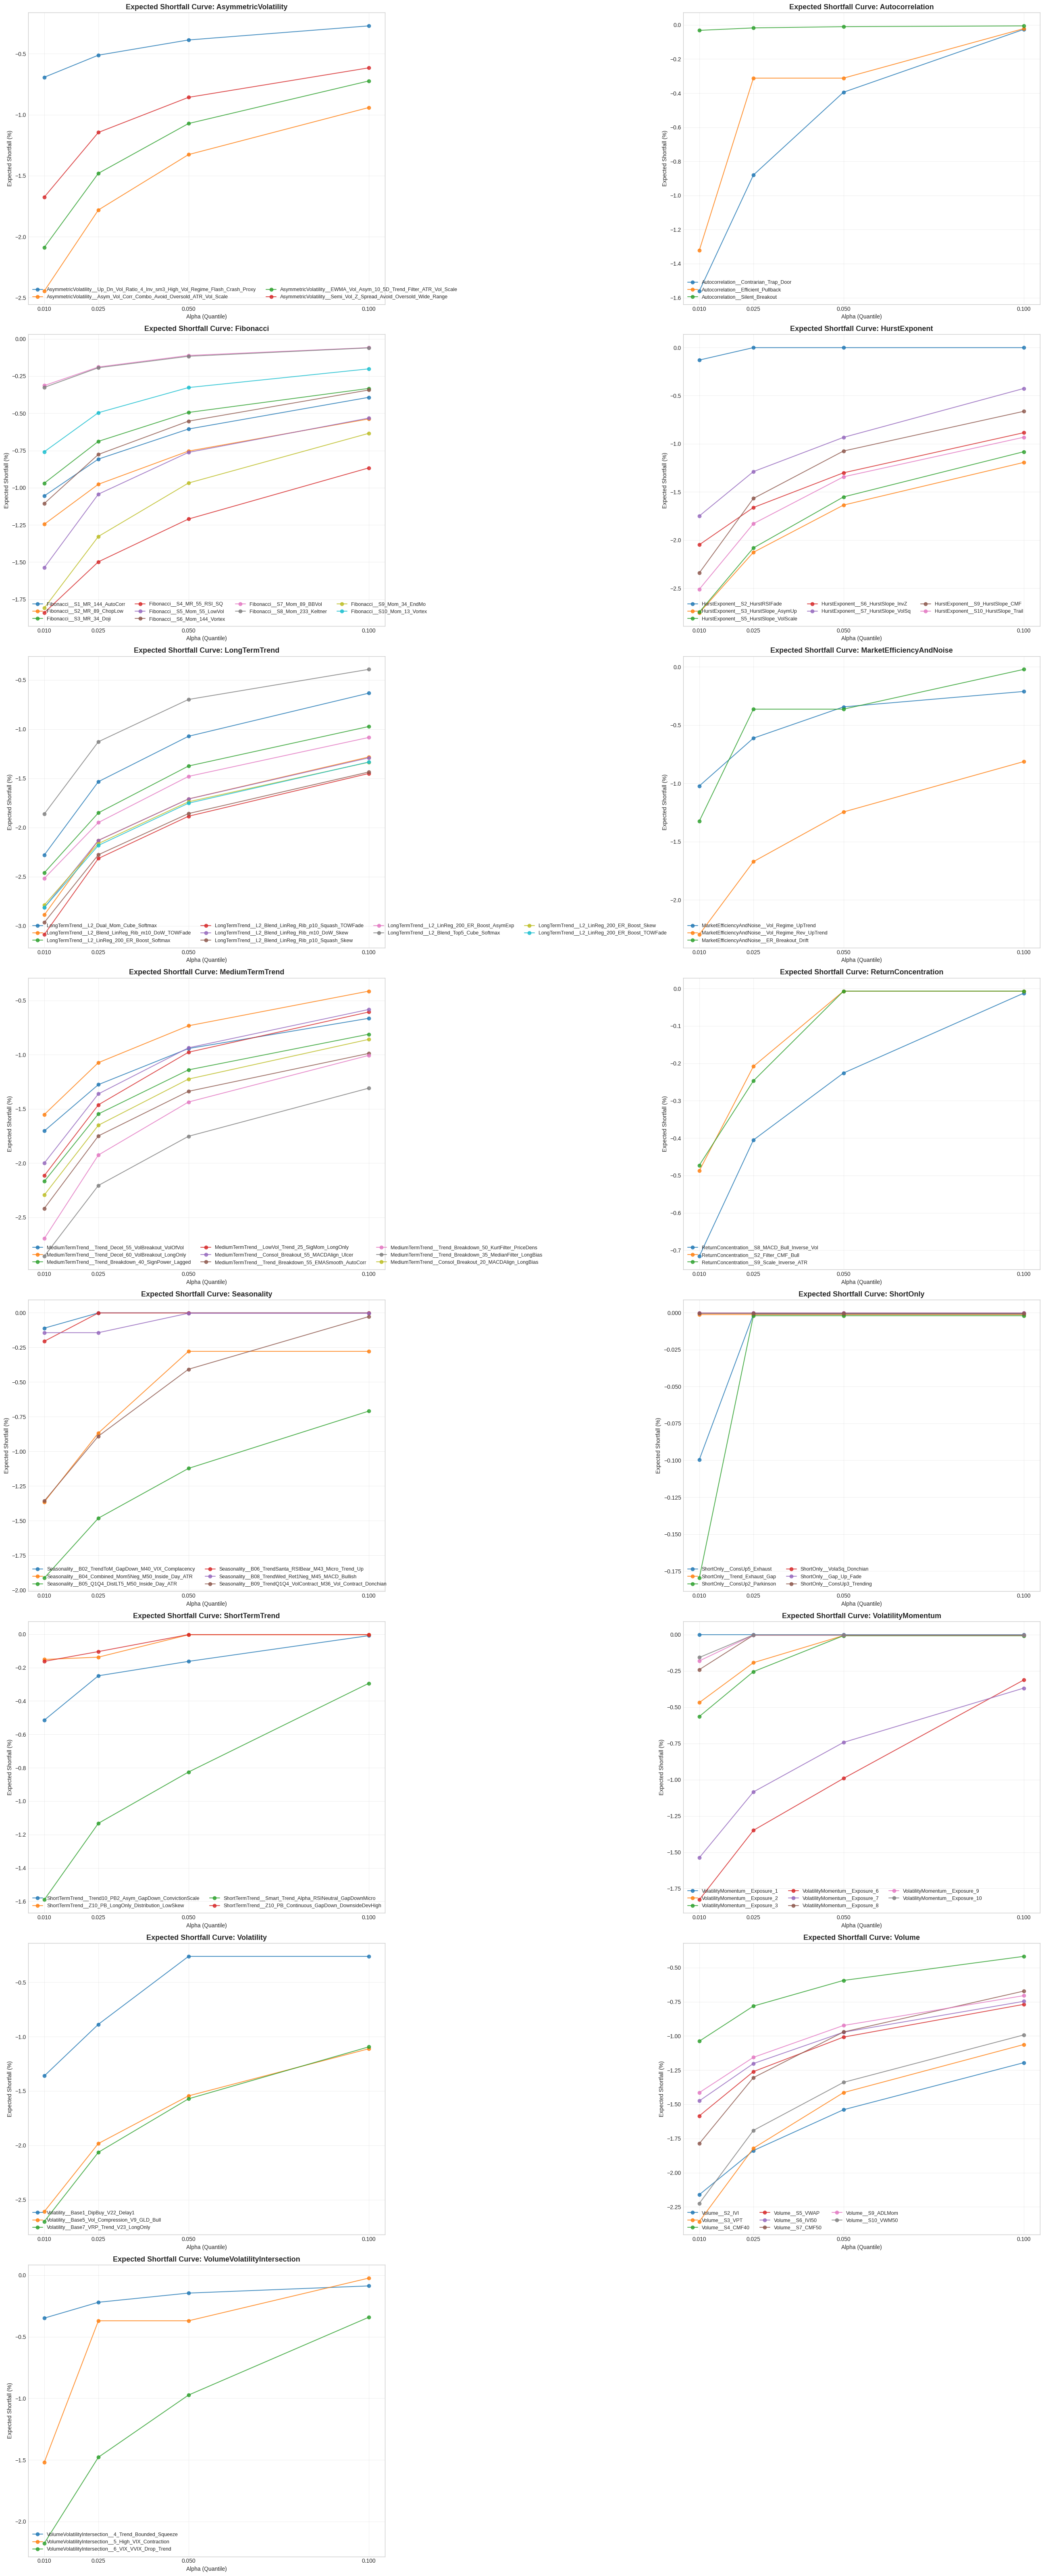


Generating Drawdown Duration Distributions...


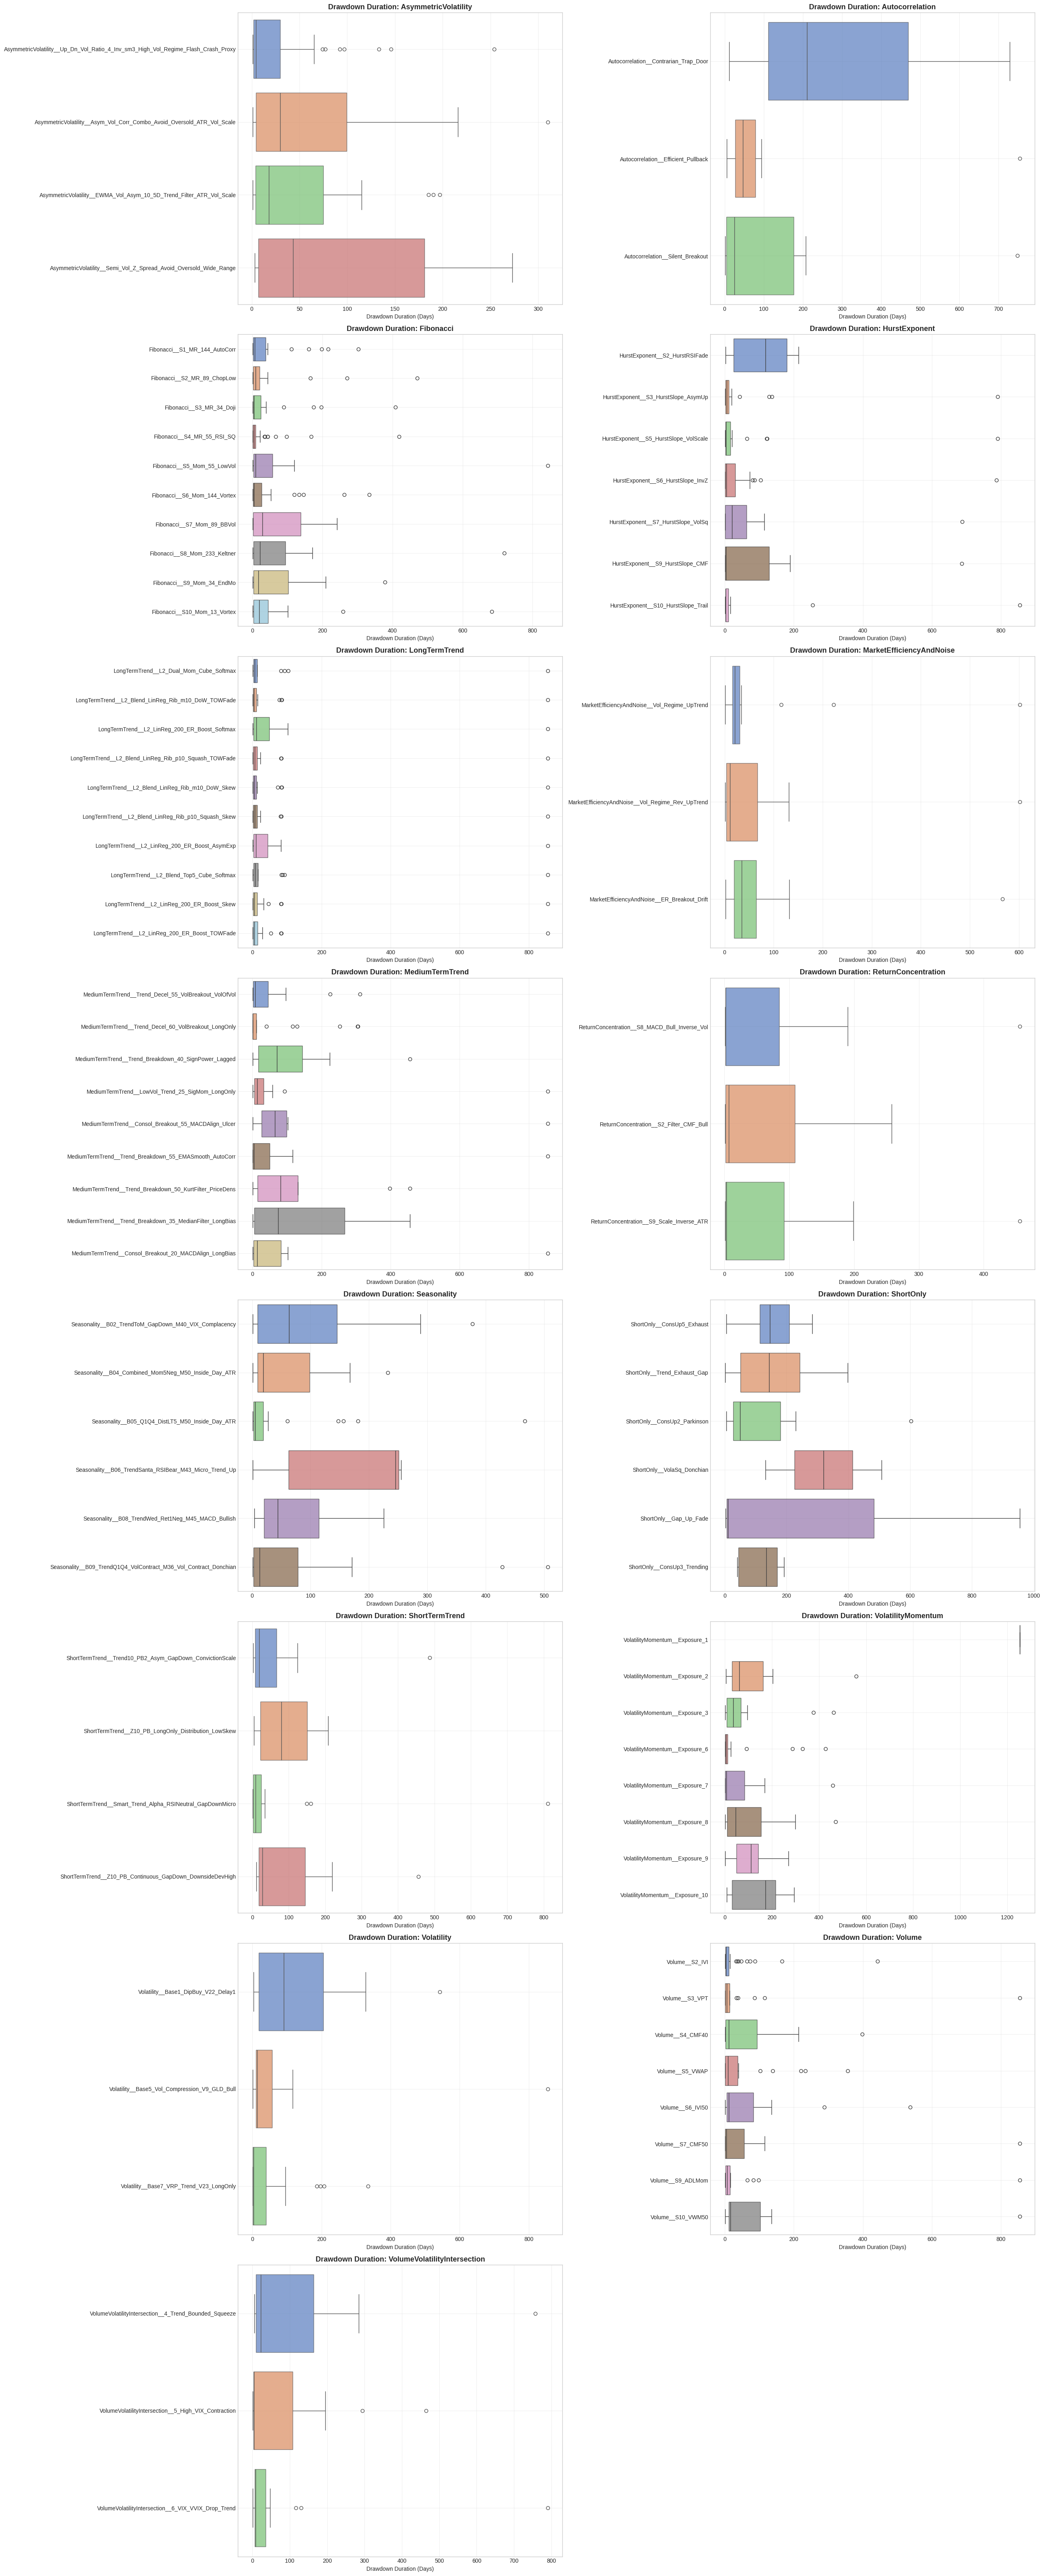

✅ Risk profile plotting complete. Proceed to Final Scorecard.


In [11]:
# ==============================================================================
# CELL 11: RISK PROFILES
# ==============================================================================
print("Plotting Risk Profiles for ALL Signals (Grouped by Family)...")

def calculate_dd_durations(ret: pd.Series) -> list:
    if len(ret) == 0: return[]
    cum = (1 + ret).cumprod()
    dd = cum / cum.cummax() - 1
    durations =[]
    d = 0
    for x in dd.values:
        if x < 0:
            d += 1
        elif d > 0:
            durations.append(d)
            d = 0
    if d > 0: durations.append(d)
    return durations

valid_groups = {grp: keys for grp, keys in SIG_GROUPS.items() if any(k in ALL_SIGS for k in keys)}
n_groups = len(valid_groups)

cols = 2
rows = math.ceil(n_groups / cols)

# ------------------------------------------------------------------------------
# PART 1: EXPECTED SHORTFALL CURVES
# ------------------------------------------------------------------------------
print("Generating Expected Shortfall Curves...")
fig1, axes1 = plt.subplots(rows, cols, figsize=(26, 8 * rows))
axes1 = axes1.flatten()

for idx, (grp, keys) in enumerate(valid_groups.items()):
    ax = axes1[idx]
    plot_count = 0

    for name in keys:
        if name not in ALL_SIGS: continue

        _, net, _, _ = compute_returns(ALL_SIGS[name], test_mask)
        r = net.fillna(0)

        es_vals =[]
        for a in ES_ALPHAS:
            tail = r[r <= np.quantile(r, a)]
            es = np.mean(tail) * 100 if len(tail) > 0 else 0.0
            es_vals.append(es)

        ax.plot(ES_ALPHAS, es_vals, marker="o", lw=1.5, alpha=0.8, label=name)
        plot_count += 1

    ax.set_title(f"Expected Shortfall Curve: {grp}", fontweight="bold", fontsize=13)
    ax.set_xlabel("Alpha (Quantile)")
    ax.set_ylabel("Expected Shortfall (%)")
    ax.set_xticks(ES_ALPHAS)

    if plot_count > 0:
        ax.legend(fontsize=9, ncol=max(1, math.ceil(plot_count / 3)), loc="lower left")

    ax.grid(True, alpha=0.3)

for i in range(n_groups, len(axes1)):
    fig1.delaxes(axes1[i])

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# PART 2: DRAWDOWN DURATION DISTRIBUTIONS
# ------------------------------------------------------------------------------
print("\nGenerating Drawdown Duration Distributions...")
fig2, axes2 = plt.subplots(rows, cols, figsize=(26, 8 * rows))
axes2 = axes2.flatten()

for idx, (grp, keys) in enumerate(valid_groups.items()):
    ax = axes2[idx]
    dd_records =[]

    for name in keys:
        if name not in ALL_SIGS: continue

        _, net, _, _ = compute_returns(ALL_SIGS[name], test_mask)
        r = net.fillna(0)
        durs = calculate_dd_durations(r)

        for d in durs:
            dd_records.append({"Signal": name, "Duration": d})

    if dd_records:
        df_dd = pd.DataFrame(dd_records)
        sns.boxplot(data=df_dd, y="Signal", x="Duration", ax=ax,
                    palette="muted", boxprops=dict(alpha=0.7))
        ax.set_title(f"Drawdown Duration: {grp}", fontweight="bold", fontsize=13)
        ax.set_xlabel("Drawdown Duration (Days)")
        ax.set_ylabel("")
    else:
        ax.set_title(f"Drawdown Duration: {grp} (No Drawdowns)", fontweight="bold", fontsize=13)

    ax.grid(True, alpha=0.3)

for i in range(n_groups, len(axes2)):
    fig2.delaxes(axes2[i])

plt.tight_layout()
plt.show()

print("✅ Risk profile plotting complete. Proceed to Final Scorecard.")

# Research Quality Score With Gates

In [13]:
# ==============================================================================
# CELL 12: FINAL SCORECARD AND GATING
# ==============================================================================
print("Assembling Signal Leaderboard...")

# ------------------------------------------------------------------------------
# Part 1: Gate policy
# ------------------------------------------------------------------------------
GATE_MIN_TEST_SHARPE = max(float(globals().get("GATE_MIN_TEST_SHARPE", 0.75)), 0.75)
GATE_MIN_DSR = max(float(globals().get("GATE_MIN_DSR", 0.80)), 0.80)
GATE_MAX_TURNOVER = min(float(globals().get("GATE_MAX_TURNOVER", 0.40)), 0.40)
GATE_MAX_PBO = min(float(globals().get("GATE_MAX_PBO", 0.20)), 0.20)
GATE_MIN_CPCV_SHARPE = max(float(globals().get("GATE_MIN_CPCV_SHARPE", 0.20)), 0.20)
GATE_MIN_WFE = max(float(globals().get("GATE_MIN_WFE", 0.50)), 0.50)
REQUIRE_WFE_GATE = bool(globals().get("REQUIRE_WFE_GATE", True))

DEPLOY_MIN_TOTAL_SCORE = float(globals().get("DEPLOY_MIN_TOTAL_SCORE", 65.0))
MONITOR_MIN_TOTAL_SCORE = float(globals().get("MONITOR_MIN_TOTAL_SCORE", 50.0))
MONITOR_MAX_CORE_FAILURES = int(globals().get("MONITOR_MAX_CORE_FAILURES", 1))

print(
    "Gate policy: "
    f"Sharpe>={GATE_MIN_TEST_SHARPE}, "
    f"DSR>={GATE_MIN_DSR}, "
    f"CPCV Sharpe>={GATE_MIN_CPCV_SHARPE}, "
    f"PBO<={GATE_MAX_PBO}, "
    f"Turnover<={GATE_MAX_TURNOVER}, "
    f"WFE>={GATE_MIN_WFE} (required={REQUIRE_WFE_GATE}), "
    f"DeployScore>={DEPLOY_MIN_TOTAL_SCORE}, "
    f"MonitorScore>={MONITOR_MIN_TOTAL_SCORE}")

def calculate_dd_durations(ret: pd.Series) -> list:
    if len(ret) == 0:
        return []
    cum = (1 + ret).cumprod()
    dd = cum / cum.cummax() - 1
    durations = []
    d = 0
    for x in dd.values:
        if x < 0:
            d += 1
        elif d > 0:
            durations.append(d)
            d = 0
    if d > 0:
        durations.append(d)
    return durations

def winsor_minmax_score(series: pd.Series, higher_is_better: bool = True) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    valid = s.dropna()
    out = pd.Series(np.nan, index=s.index, dtype=float)

    if len(valid) == 0:
        return out

    lo, hi = np.nanpercentile(valid.values, [1, 99])
    clipped = s.clip(lower=lo, upper=hi)
    vmin = np.nanmin(clipped.values)
    vmax = np.nanmax(clipped.values)

    if not np.isfinite(vmin) or not np.isfinite(vmax) or abs(vmax - vmin) < 1e-12:
        scaled = pd.Series(50.0, index=s.index)
    else:
        scaled = 100.0 * (clipped - vmin) / (vmax - vmin)

    if not higher_is_better:
        scaled = 100.0 - scaled

    out.loc[scaled.index] = scaled
    return out.clip(0, 100)

def winsor_minmax_score_nan_zero_valid_positive(series: pd.Series, higher_is_better: bool = True) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    valid = s.dropna()

    out = pd.Series(0.0, index=s.index, dtype=float)

    if len(valid) == 0:
        return out

    lo, hi = np.nanpercentile(valid.values, [1, 99])
    clipped_valid = valid.clip(lower=lo, upper=hi)

    vmin = np.nanmin(clipped_valid.values)
    vmax = np.nanmax(clipped_valid.values)

    if not np.isfinite(vmin) or not np.isfinite(vmax) or abs(vmax - vmin) < 1e-12:
        scaled_valid = pd.Series(50.0, index=valid.index)
    else:
        scaled_valid = 100.0 * (clipped_valid - vmin) / (vmax - vmin)

    if not higher_is_better:
        scaled_valid = 100.0 - scaled_valid

    scaled_valid = 1.0 + 99.0 * (scaled_valid / 100.0)

    out.loc[scaled_valid.index] = scaled_valid
    return out.clip(0, 100)

# ------------------------------------------------------------------------------
# PART 2: BUILD RAW METRICS
# ------------------------------------------------------------------------------
rows = []
for name, sig in ALL_SIGS.items():
    te_m = base_metrics.get(name, {}).get("Test", {})
    w_m = wfo_results.get(name, {})
    cpcv_m = cpcv_results.get(name, {})
    cscv_m = cscv_results.get(name, {})

    fdr_sig = False
    if "df_fdr" in globals() and name in df_fdr.index:
        fdr_sig = bool(df_fdr.loc[name].get("BH_significant", False))

    _, net, _, _ = compute_returns(sig, test_mask)
    r = net.fillna(0)
    durs = calculate_dd_durations(r)

    rows.append({
        "Signal": name,
        "Test_Sharpe": te_m.get("NetSharpe", np.nan),
        "Test_DSR": te_m.get("DSR", np.nan),
        "Test_Turnover": te_m.get("Turnover", np.nan),
        "WFE_Median": w_m.get("WFE_Median", np.nan),
        "CPCV_MedianTestSharpe": cpcv_m.get("CPCV_MedianTestSharpe", np.nan),
        "Signal_PBO": cscv_m.get("Signal_PBO", np.nan),
        "Median_Rank_Ratio": cscv_m.get("Median_Rank_Ratio", np.nan),
        "Degradation": cscv_m.get("Degradation", np.nan),
        "BH_significant": fdr_sig,
        "TestMaxDD_Days": int(max(durs) if durs else 0),
        "ES": te_m.get("ES_5", np.nan)})

leaderboard = pd.DataFrame(rows).set_index("Signal")

lower_is_better = {
    "Signal_PBO", "Median_Rank_Ratio", "Degradation", "TestMaxDD_Days", "Test_Turnover"}

metric_cfg = {
    "Test_Sharpe": True,
    "Test_DSR": True,
    "WFE_Median": True,
    "CPCV_MedianTestSharpe": True,
    "Signal_PBO": False,
    "Median_Rank_Ratio": False,
    "Degradation": False,
    "TestMaxDD_Days": False,
    "ES": True,
    "Test_Turnover": False}

for col, hib in metric_cfg.items():
    if col in {"Signal_PBO", "Degradation"}:
        leaderboard[f"SubScore_{col}"] = winsor_minmax_score_nan_zero_valid_positive(
            leaderboard[col], higher_is_better=hib)
    else:
        leaderboard[f"SubScore_{col}"] = winsor_minmax_score(
            leaderboard[col], higher_is_better=hib)

leaderboard["SubScore_BH_significant"] = np.where(leaderboard["BH_significant"], 100.0, 0.0)

# ------------------------------------------------------------------------------
# PART 3: BUILD WEIGHTED SCORE
# ------------------------------------------------------------------------------
weights = {
    "SubScore_Test_Sharpe": 15,
    "SubScore_CPCV_MedianTestSharpe": 15,
    "SubScore_WFE_Median": 10,
    "SubScore_Test_DSR": 15,
    "SubScore_BH_significant": 10,
    "SubScore_Signal_PBO": 10,
    "SubScore_Degradation": 10,
    "SubScore_ES": 5,
    "SubScore_TestMaxDD_Days": 5,
    "SubScore_Median_Rank_Ratio": 3,
    "SubScore_Test_Turnover": 2}

weight_sum = float(sum(weights.values()))
leaderboard["TotalScore"] = 0.0
for col, w in weights.items():
    leaderboard["TotalScore"] += (w / weight_sum) * leaderboard[col]

# ------------------------------------------------------------------------------
# PART 4: HARD GATES
# ------------------------------------------------------------------------------
leaderboard["Gate_TestSharpe"] = leaderboard["Test_Sharpe"] >= GATE_MIN_TEST_SHARPE
leaderboard["Gate_CPCV"] = leaderboard["CPCV_MedianTestSharpe"] >= GATE_MIN_CPCV_SHARPE
leaderboard["Gate_DSR"] = leaderboard["Test_DSR"] >= GATE_MIN_DSR
leaderboard["Gate_BH"] = leaderboard["BH_significant"]
leaderboard["Gate_PBO"] = leaderboard["Signal_PBO"] <= GATE_MAX_PBO
leaderboard["Gate_Turnover"] = leaderboard["Test_Turnover"] <= GATE_MAX_TURNOVER
leaderboard["Gate_WFE"] = leaderboard["WFE_Median"] >= GATE_MIN_WFE

if REQUIRE_WFE_GATE:
    leaderboard["Gate_DeployPass"] = (
        leaderboard["Gate_TestSharpe"]
        & leaderboard["Gate_CPCV"]
        & leaderboard["Gate_DSR"]
        & leaderboard["Gate_BH"]
        & leaderboard["Gate_PBO"]
        & leaderboard["Gate_Turnover"]
        & leaderboard["Gate_WFE"])
else:
    leaderboard["Gate_DeployPass"] = (
        leaderboard["Gate_TestSharpe"]
        & leaderboard["Gate_CPCV"]
        & leaderboard["Gate_DSR"]
        & leaderboard["Gate_BH"]
        & leaderboard["Gate_PBO"]
        & leaderboard["Gate_Turnover"])

core_gates = [
    "Gate_TestSharpe", "Gate_CPCV", "Gate_DSR", "Gate_BH", "Gate_PBO", "Gate_Turnover"]
if REQUIRE_WFE_GATE:
    core_gates = core_gates + ["Gate_WFE"]

leaderboard["CoreGateFailures"] = (~leaderboard[core_gates]).sum(axis=1)

leaderboard["Gate_DeployScoreFloor"] = leaderboard["TotalScore"] >= DEPLOY_MIN_TOTAL_SCORE
leaderboard["Gate_MonitorScoreFloor"] = leaderboard["TotalScore"] >= MONITOR_MIN_TOTAL_SCORE
leaderboard["Gate_MonitorCoreFailures"] = leaderboard["CoreGateFailures"] <= MONITOR_MAX_CORE_FAILURES

leaderboard["FinalLabel"] = np.where(
    leaderboard["Gate_DeployPass"] & leaderboard["Gate_DeployScoreFloor"],
    "Deploy",
    np.where(
        leaderboard["Gate_MonitorScoreFloor"] & leaderboard["Gate_MonitorCoreFailures"],
        "Monitor",
        "Research"))

leaderboard = leaderboard.sort_values("TotalScore", ascending=False)

decision_cols = [
    "TotalScore", "FinalLabel", "CoreGateFailures",
    "Gate_DeployPass", "Gate_DeployScoreFloor", "Gate_MonitorScoreFloor", "Gate_MonitorCoreFailures",
    "Gate_TestSharpe", "Gate_CPCV", "Gate_DSR", "Gate_BH", "Gate_PBO", "Gate_Turnover", "Gate_WFE",
    "Test_Sharpe", "CPCV_MedianTestSharpe", "Test_DSR", "Signal_PBO", "Test_Turnover", "WFE_Median"]
decision_packet = leaderboard[decision_cols].copy()

try:
    decision_packet.to_csv("cell11_decision_packet.csv")
    print("Saved decision packet: cell11_decision_packet.csv")
except Exception as e:
    print(f"Could not save decision packet CSV: {e}")

gate_table_cols = ["TotalScore", "CoreGateFailures", "Gate_DeployPass", "FinalLabel"]
gate_table = leaderboard[gate_table_cols].copy()

detail_cols = [c for c in leaderboard.columns if c not in gate_table_cols]
detail_table = leaderboard[detail_cols].copy()

def style_with_direction(df: pd.DataFrame, lower_better_cols=None, caption=""):
    if lower_better_cols is None:
        lower_better_cols = []

    s = df.style.set_caption(caption)

    bool_cols = [c for c in df.columns if pd.api.types.is_bool_dtype(df[c])]
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c not in bool_cols]
    cat_cols = [c for c in df.columns if c not in num_cols and c not in bool_cols]

    lower_num = [c for c in num_cols if c in lower_better_cols]
    higher_num = [c for c in num_cols if c not in lower_num]

    if higher_num:
        s = s.background_gradient(cmap="RdYlGn", subset=higher_num)
    if lower_num:
        s = s.background_gradient(cmap="RdYlGn_r", subset=lower_num)

    def bool_color(v):
        if pd.isna(v):
            return "background-color:#000000;color:#ffffff;font-weight:700;"
        return (
            "background-color:#c6efce;color:#006100;font-weight:600;"
            if bool(v)
            else "background-color:#ffc7ce;color:#9c0006;font-weight:600;")

    for c in bool_cols:
        s = s.map(bool_color, subset=[c])

    for c in cat_cols:
        if c == "FinalLabel":
            def label_color(v):
                if pd.isna(v):
                    return "background-color:#000000;color:#ffffff;font-weight:700;"
                if v == "Deploy":
                    return "background-color:#c6efce;color:#006100;font-weight:700;"
                if v == "Monitor":
                    return "background-color:#ffeb9c;color:#9c6500;font-weight:700;"
                if v == "Research":
                    return "background-color:#ffc7ce;color:#9c0006;font-weight:700;"
                return "background-color:#f7f7f7;color:#666;"
            s = s.map(label_color, subset=[c])
        else:
            s = s.map(lambda v: "background-color:#000000;color:#ffffff;font-weight:700;" if pd.isna(v) else "background-color:#f7f7f7;", subset=[c])

    def nan_black(v):
        return "background-color:#000000;color:#ffffff;font-weight:700;" if pd.isna(v) else ""

    s = s.map(nan_black)

    s = s.format(precision=3).set_properties(**{
        "border": "1px solid #ddd",
        "text-align": "center"})
    return s

detail_lower_cols = [c for c in lower_is_better if c in detail_table.columns]

print("\nFinal Gate Table:")
display(style_with_direction(gate_table, lower_better_cols=[], caption="Final Gate View"))

print("\nDetail Table:")
display(style_with_direction(detail_table, lower_better_cols=detail_lower_cols, caption="Detailed Metrics & Subscores"))

print("\nDecision Packet:")
pd.set_option("display.max_rows", None)
display(decision_packet)

Assembling Signal Leaderboard...
Gate policy: Sharpe>=0.75, DSR>=0.8, CPCV Sharpe>=0.2, PBO<=0.2, Turnover<=0.4, WFE>=0.5 (required=True), DeployScore>=65.0, MonitorScore>=50.0
Saved decision packet: cell11_decision_packet.csv

Final Gate Table:


,TotalScore,CoreGateFailures,Gate_DeployPass,FinalLabel
Signal,,,,
ReturnConcentration__S2_Filter_CMF_Bull,82.261,1,False,Monitor
ReturnConcentration__S8_MACD_Bull_Inverse_Vol,78.756,1,False,Monitor
ReturnConcentration__S9_Scale_Inverse_ATR,73.380,2,False,Research
LongTermTrend__L2_Blend_LinReg_Rib_p10_Squash_Skew,57.854,3,False,Research
Seasonality__B05_Q1Q4_DistLT5_M50_Inside_Day_ATR,56.303,2,False,Research
LongTermTrend__L2_LinReg_200_ER_Boost_Skew,56.164,3,False,Research
LongTermTrend__L2_Dual_Mom_Cube_Softmax,51.668,4,False,Research
MediumTermTrend__Trend_Decel_60_VolBreakout_LongOnly,50.177,3,False,Research
LongTermTrend__L2_Blend_Top5_Cube_Softmax,48.750,5,False,Research



Detail Table:


,Test_Sharpe,Test_DSR,Test_Turnover,WFE_Median,CPCV_MedianTestSharpe,Signal_PBO,Median_Rank_Ratio,Degradation,BH_significant,TestMaxDD_Days,ES,SubScore_Test_Sharpe,SubScore_Test_DSR,SubScore_WFE_Median,SubScore_CPCV_MedianTestSharpe,SubScore_Signal_PBO,SubScore_Median_Rank_Ratio,SubScore_Degradation,SubScore_TestMaxDD_Days,SubScore_ES,SubScore_Test_Turnover,SubScore_BH_significant,Gate_TestSharpe,Gate_CPCV,Gate_DSR,Gate_BH,Gate_PBO,Gate_Turnover,Gate_WFE,Gate_DeployScoreFloor,Gate_MonitorScoreFloor,Gate_MonitorCoreFailures
Signal,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ReturnConcentration__S2_Filter_CMF_Bull,1.683,0.841,0.009,1.329,0.970,0.000,0.989,0.182,False,258,-0.007,96.435,97.573,66.010,100.000,100.000,0.000,100.000,92.293,99.624,98.164,0.000,True,True,True,False,True,True,True,True,True,True
ReturnConcentration__S8_MACD_Bull_Inverse_Vol,1.780,0.872,0.011,0.924,0.872,0.020,0.989,0.358,False,456,-0.226,100.000,100.000,58.455,97.165,98.020,0.000,88.144,67.560,87.855,97.408,0.000,True,True,True,False,True,True,True,True,True,True
ReturnConcentration__S9_Scale_Inverse_ATR,1.752,0.860,0.009,1.095,0.896,0.385,0.977,0.725,False,456,-0.007,99.808,99.806,61.643,99.148,61.923,1.213,58.557,67.560,99.624,97.912,0.000,True,True,True,False,False,True,True,True,True,False
LongTermTrend__L2_Blend_LinReg_Rib_p10_Squash_Skew,0.670,0.808,0.023,0.005,0.579,0.000,0.897,0.382,False,855,-1.857,46.663,93.757,41.290,73.127,100.000,9.706,86.226,17.720,0.211,94.132,0.000,False,True,True,False,True,True,False,False,True,False
Seasonality__B05_Q1Q4_DistLT5_M50_Inside_Day_ATR,1.009,0.313,0.125,1.696,0.576,0.000,0.862,0.689,False,467,-1.123,63.319,36.222,72.873,72.932,100.000,13.346,61.408,66.186,39.654,65.598,0.000,True,True,False,False,True,True,True,False,True,False
LongTermTrend__L2_LinReg_200_ER_Boost_Skew,0.632,0.785,0.032,0.554,0.574,0.000,0.885,0.665,False,855,-1.738,44.813,91.093,51.535,72.751,100.000,10.920,63.361,17.720,6.605,91.584,0.000,False,True,False,False,True,True,True,False,True,False
LongTermTrend__L2_Dual_Mom_Cube_Softmax,0.688,0.813,0.025,0.156,0.278,0.333,0.839,0.625,False,855,-1.072,47.567,94.339,44.108,48.435,67.000,15.773,66.574,17.720,42.394,93.488,0.000,False,True,True,False,False,True,False,False,True,False
MediumTermTrend__Trend_Decel_60_VolBreakout_LongOnly,0.815,0.573,0.062,1.125,0.410,1.000,0.724,0.572,False,306,-0.734,53.777,66.432,62.206,59.303,1.000,27.906,70.846,86.297,60.557,83.267,0.000,True,True,False,False,False,True,True,False,True,False
LongTermTrend__L2_Blend_Top5_Cube_Softmax,0.645,0.777,0.011,-1.052,0.396,0.462,0.914,0.719,False,855,-0.698,45.436,90.174,21.552,58.162,54.308,7.886,59.047,17.720,62.492,97.324,0.000,False,True,False,False,False,True,False,False,False,False



Decision Packet:


,TotalScore,FinalLabel,CoreGateFailures,Gate_DeployPass,Gate_DeployScoreFloor,Gate_MonitorScoreFloor,Gate_MonitorCoreFailures,Gate_TestSharpe,Gate_CPCV,Gate_DSR,Gate_BH,Gate_PBO,Gate_Turnover,Gate_WFE,Test_Sharpe,CPCV_MedianTestSharpe,Test_DSR,Signal_PBO,Test_Turnover,WFE_Median
Signal,,,,,,,,,,,,,,,,,,,,
ReturnConcentration__S2_Filter_CMF_Bull,82.2613,Monitor,1,False,True,True,True,True,True,True,False,True,True,True,1.6835,0.9700,0.8405,0.0000,0.0085,1.3287
ReturnConcentration__S8_MACD_Bull_Inverse_Vol,78.7555,Monitor,1,False,True,True,True,True,True,True,False,True,True,True,1.7802,0.8717,0.8716,0.0200,0.0112,0.9240
ReturnConcentration__S9_Scale_Inverse_ATR,73.3804,Research,2,False,True,True,False,True,True,True,False,False,True,True,1.7522,0.8958,0.8597,0.3846,0.0094,1.0948
LongTermTrend__L2_Blend_LinReg_Rib_p10_Squash_Skew,57.8541,Research,3,False,False,True,False,False,True,True,False,True,True,False,0.6696,0.5787,0.8077,0.0000,0.0229,0.0049
Seasonality__B05_Q1Q4_DistLT5_M50_Inside_Day_ATR,56.3034,Research,2,False,False,True,False,True,True,False,False,True,True,True,1.0089,0.5763,0.3131,0.0000,0.1248,1.6962
LongTermTrend__L2_LinReg_200_ER_Boost_Skew,56.1637,Research,3,False,False,True,False,False,True,False,False,True,True,True,0.6319,0.5741,0.7848,0.0000,0.0320,0.5535
LongTermTrend__L2_Dual_Mom_Cube_Softmax,51.6679,Research,4,False,False,True,False,False,True,True,False,False,True,False,0.6880,0.2777,0.8127,0.3333,0.0252,0.1557
MediumTermTrend__Trend_Decel_60_VolBreakout_LongOnly,50.1771,Research,3,False,False,True,False,True,True,False,False,False,True,True,0.8145,0.4102,0.5728,1.0000,0.0617,1.1249
LongTermTrend__L2_Blend_Top5_Cube_Softmax,48.7501,Research,5,False,False,False,False,False,True,False,False,False,True,False,0.6446,0.3963,0.7769,0.4615,0.0115,-1.0522
